In [1]:
import pandas as pd
import joblib
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PRICE_DATA_PATH = "./StockData"
SENTIMENT_FILE = "./daily_company_sentiment_scores.xlsx"

PRICE_MODEL_DIR = "price_models"
os.makedirs(PRICE_MODEL_DIR, exist_ok=True)

companies = [
    'MCPL.N0000','WATA.N0000','AGPL.N0000','HAPU.N0000',
    'KOTA.N0000','BFL.N0000','RWSL.N0000','DIPP.N0000',
    'MGT.N0000','HEXP.N0000'
]

In [2]:
sentiment_df = pd.read_excel(SENTIMENT_FILE)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

print(sentiment_df.columns)

Index(['date', 'WATA.N0000_sentiment_score', 'AGPL.N0000_sentiment_score',
       'HAPU.N0000_sentiment_score', 'MCPL.N0000_sentiment_score',
       'KOTA.N0000_sentiment_score', 'BFL.N0000_sentiment_score',
       'RWSL.N0000_sentiment_score', 'DIPP.N0000_sentiment_score',
       'MGT.N0000_sentiment_score', 'HEXP.N0000_sentiment_score'],
      dtype='object')


In [ ]:
results = []

for company in companies:

    print(f"\n==============================")
    print(f"Training RF for {company}")
    print(f"==============================")

    price_file = f"{PRICE_DATA_PATH}/{company.split('.')[0]}.csv"

    if not os.path.exists(price_file):
        print("❌ Price file missing")
        continue

    sentiment_col = f"{company}_sentiment_score"

    if sentiment_col not in sentiment_df.columns:
        print(f"❌ Sentiment column missing: {sentiment_col}")
        continue

    # -----------------------------
    # Load price data
    # -----------------------------
    df_price = pd.read_csv(price_file)
    df_price['Trade Date'] = pd.to_datetime(df_price['Trade Date'])
    df_price = df_price.sort_values('Trade Date')

    # 🔥 DROP sentiment column if it already exists (KEY FIX)
    if sentiment_col in df_price.columns:
        df_price = df_price.drop(columns=[sentiment_col])

    # -----------------------------
    # Prepare sentiment for merge
    # -----------------------------
    sentiment_subset = sentiment_df[['date', sentiment_col]].copy()

    # -----------------------------
    # Merge (SAFE)
    # -----------------------------
    df = pd.merge(
        df_price,
        sentiment_subset,
        left_on='Trade Date',
        right_on='date',
        how='left'
    )

    # Ensure column exists
    df[sentiment_col] = df[sentiment_col].fillna(0)

    # -----------------------------
    # Feature Engineering
    # -----------------------------
    df['Prev_Close'] = df['Close (Rs.)'].shift(1)
    df = df.dropna()

    X = df[['Prev_Close', sentiment_col]]
    y = df['Close (Rs.)']

    # -----------------------------
    # Time-based split
    # -----------------------------
    split = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # -----------------------------
    # Train RF
    # -----------------------------
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    # -----------------------------
    # Save model
    # -----------------------------
    model_path = f"{PRICE_MODEL_DIR}/{company}_rf.joblib"
    joblib.dump(model, model_path)

    print(f"✅ Saved → {model_path}")

    results.append({
        "Company": company,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })


In [4]:
results_df = pd.DataFrame(results)
results_df


,Company,MAE,RMSE
0,MCPL.N0000,2.03,3.04
1,WATA.N0000,3.77,4.34
2,AGPL.N0000,5.80,6.30
3,HAPU.N0000,1.22,1.73
4,KOTA.N0000,0.23,0.30
5,BFL.N0000,11.84,18.67
6,RWSL.N0000,3.59,5.00
7,DIPP.N0000,1.12,1.42
8,MGT.N0000,0.79,1.04
9,HEXP.N0000,4.65,11.53


In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 152.5 kB/s eta 0:07:49
   --------


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


ENHANCED STOCK PRICE FORECASTING WITH SENTIMENT
✓ Sentiment data loaded: 540 days
✓ Sentiment columns: ['WATA.N0000_sentiment_score', 'AGPL.N0000_sentiment_score', 'HAPU.N0000_sentiment_score', 'MCPL.N0000_sentiment_score', 'KOTA.N0000_sentiment_score']...
✓ Date range: 2023-08-16 00:00:00 to 2025-09-04 00:00:00


ENHANCED TRAINING FOR Mahaweli Coconut Plantations PLC
Company Code: MCPL.N0000
✓ Price data loaded: 811 days
  Date range: 2022-01-03 00:00:00 to 2025-10-21 00:00:00
  Price range: Rs. 24.20 - Rs. 58.80
✓ Merged data: 811 days
  Non-zero sentiment days: 309
🔍 Checking data quality for MCPL.N0000...
⚠️  Data quality issues detected:
   • Potential outliers detected: 2 days > 57.06
✓ Created 21 sentiment features

📊 Dataset Split:
  Train size: 648 days (2022-01-03 00:00:00 to 2025-02-13 00:00:00)
  Test size : 163 days (2025-02-14 00:00:00 to 2025-10-21 00:00:00)
  Target variable: Close (Rs.)

🔍 Performing enhanced grid search...
  Performing enhanced grid search for MCPL.N0

ValueError: Length of values (172) does not match length of index (171)

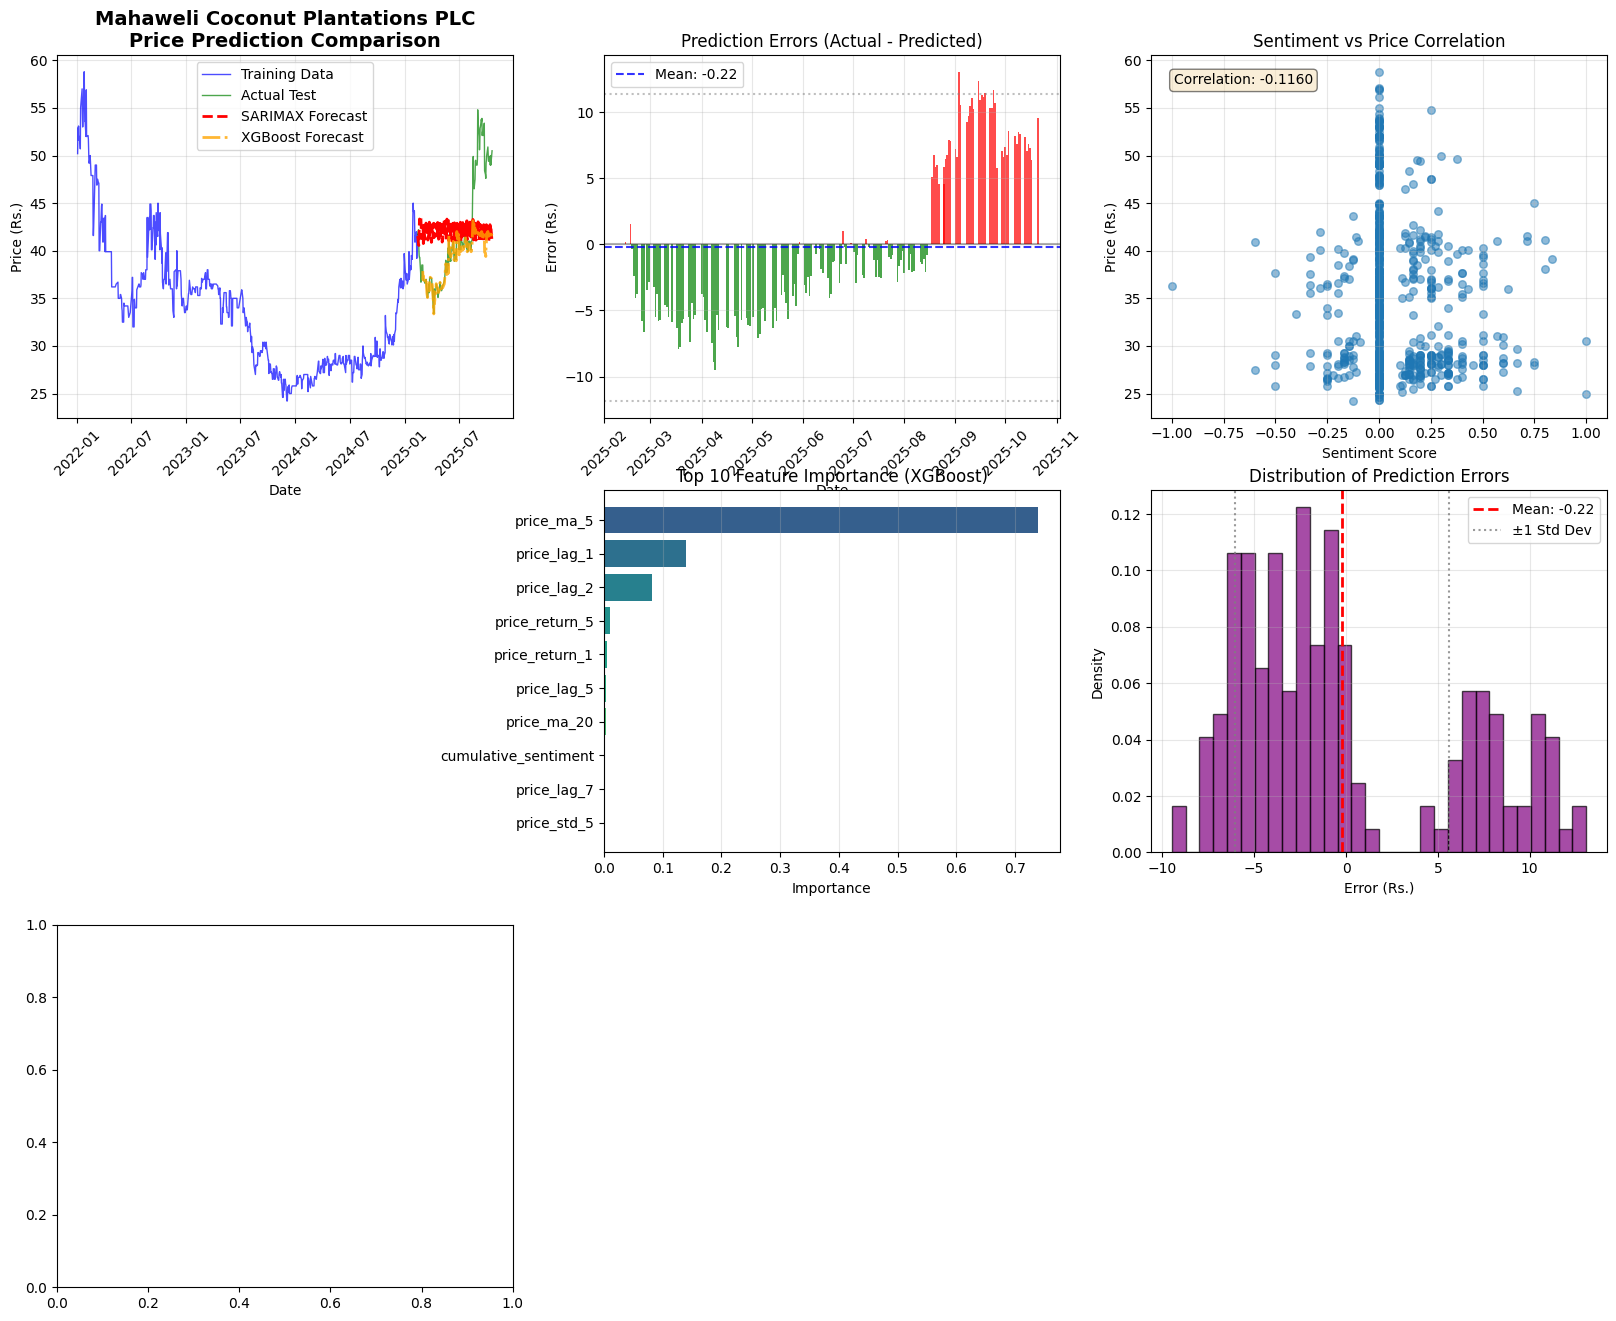

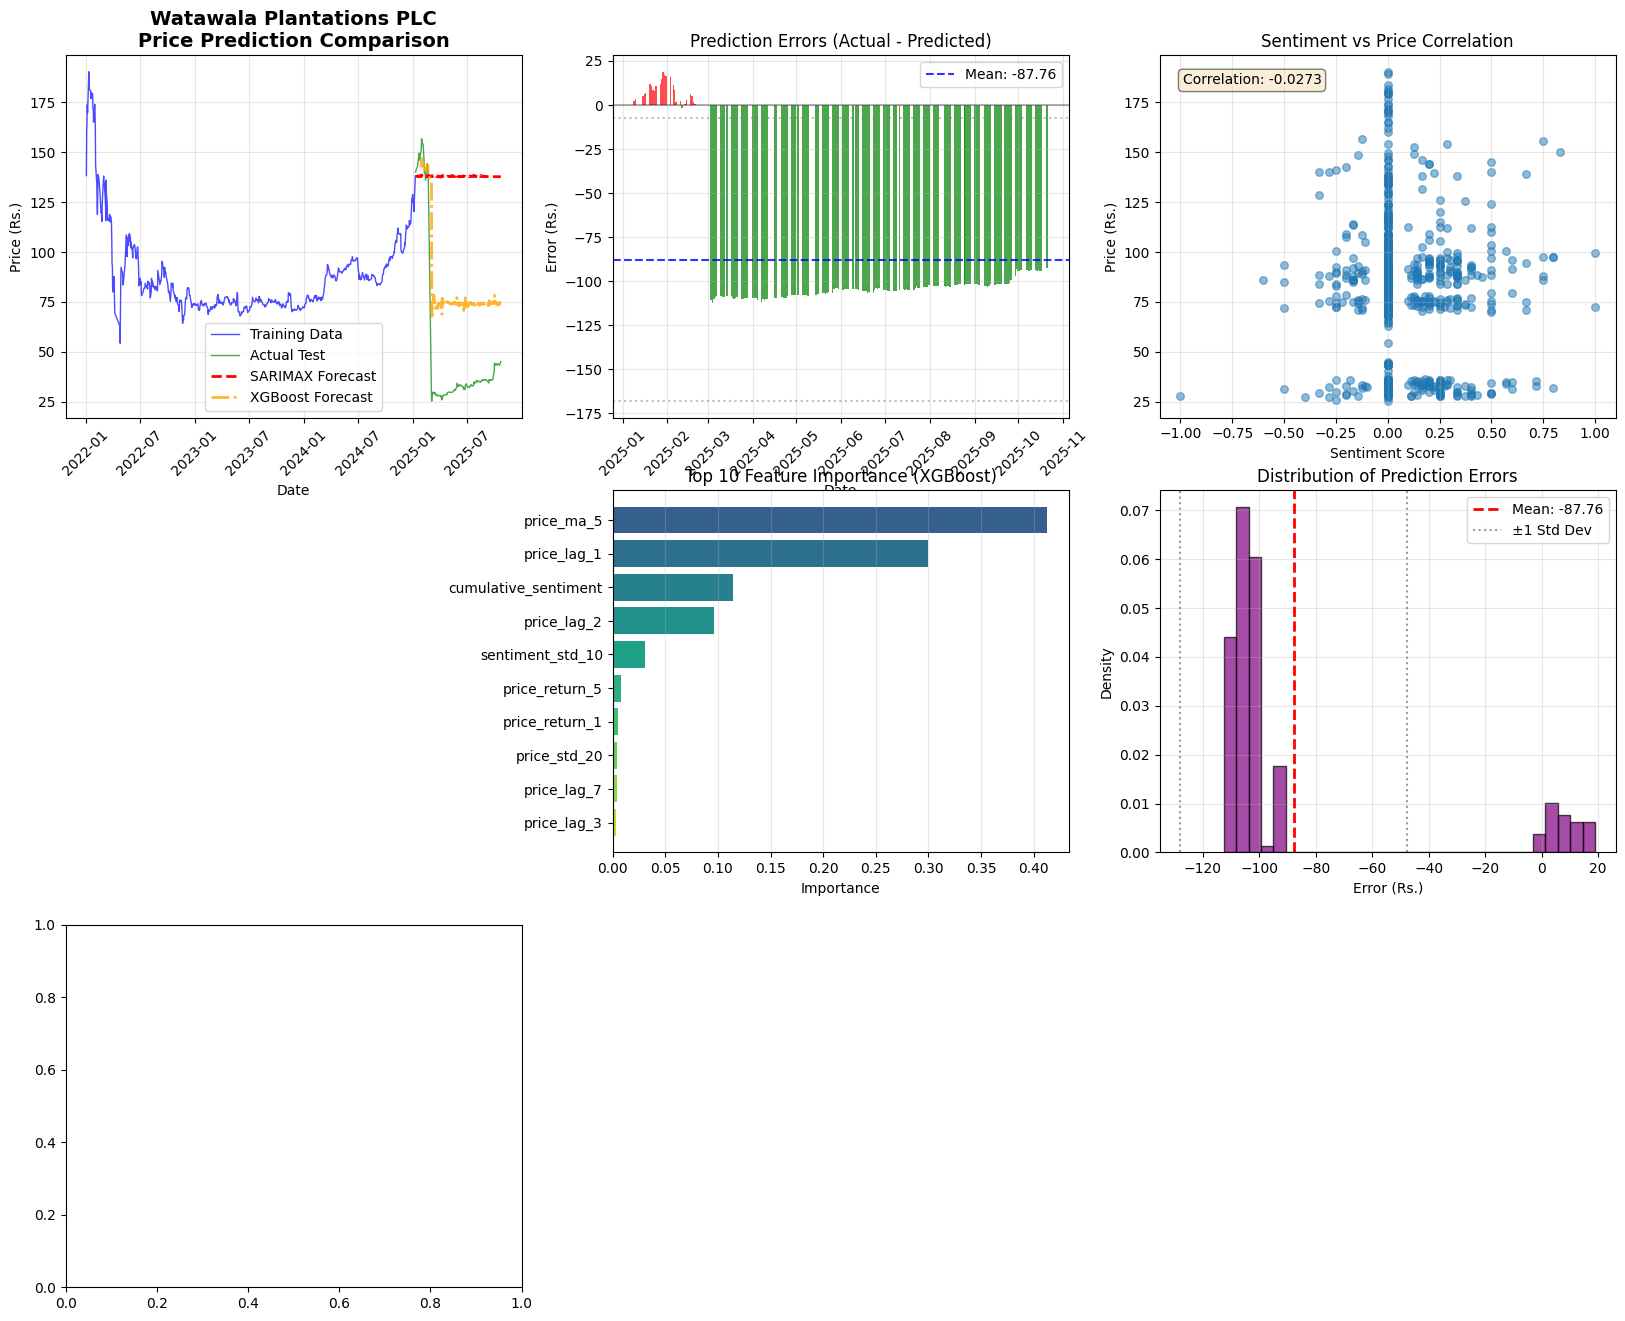

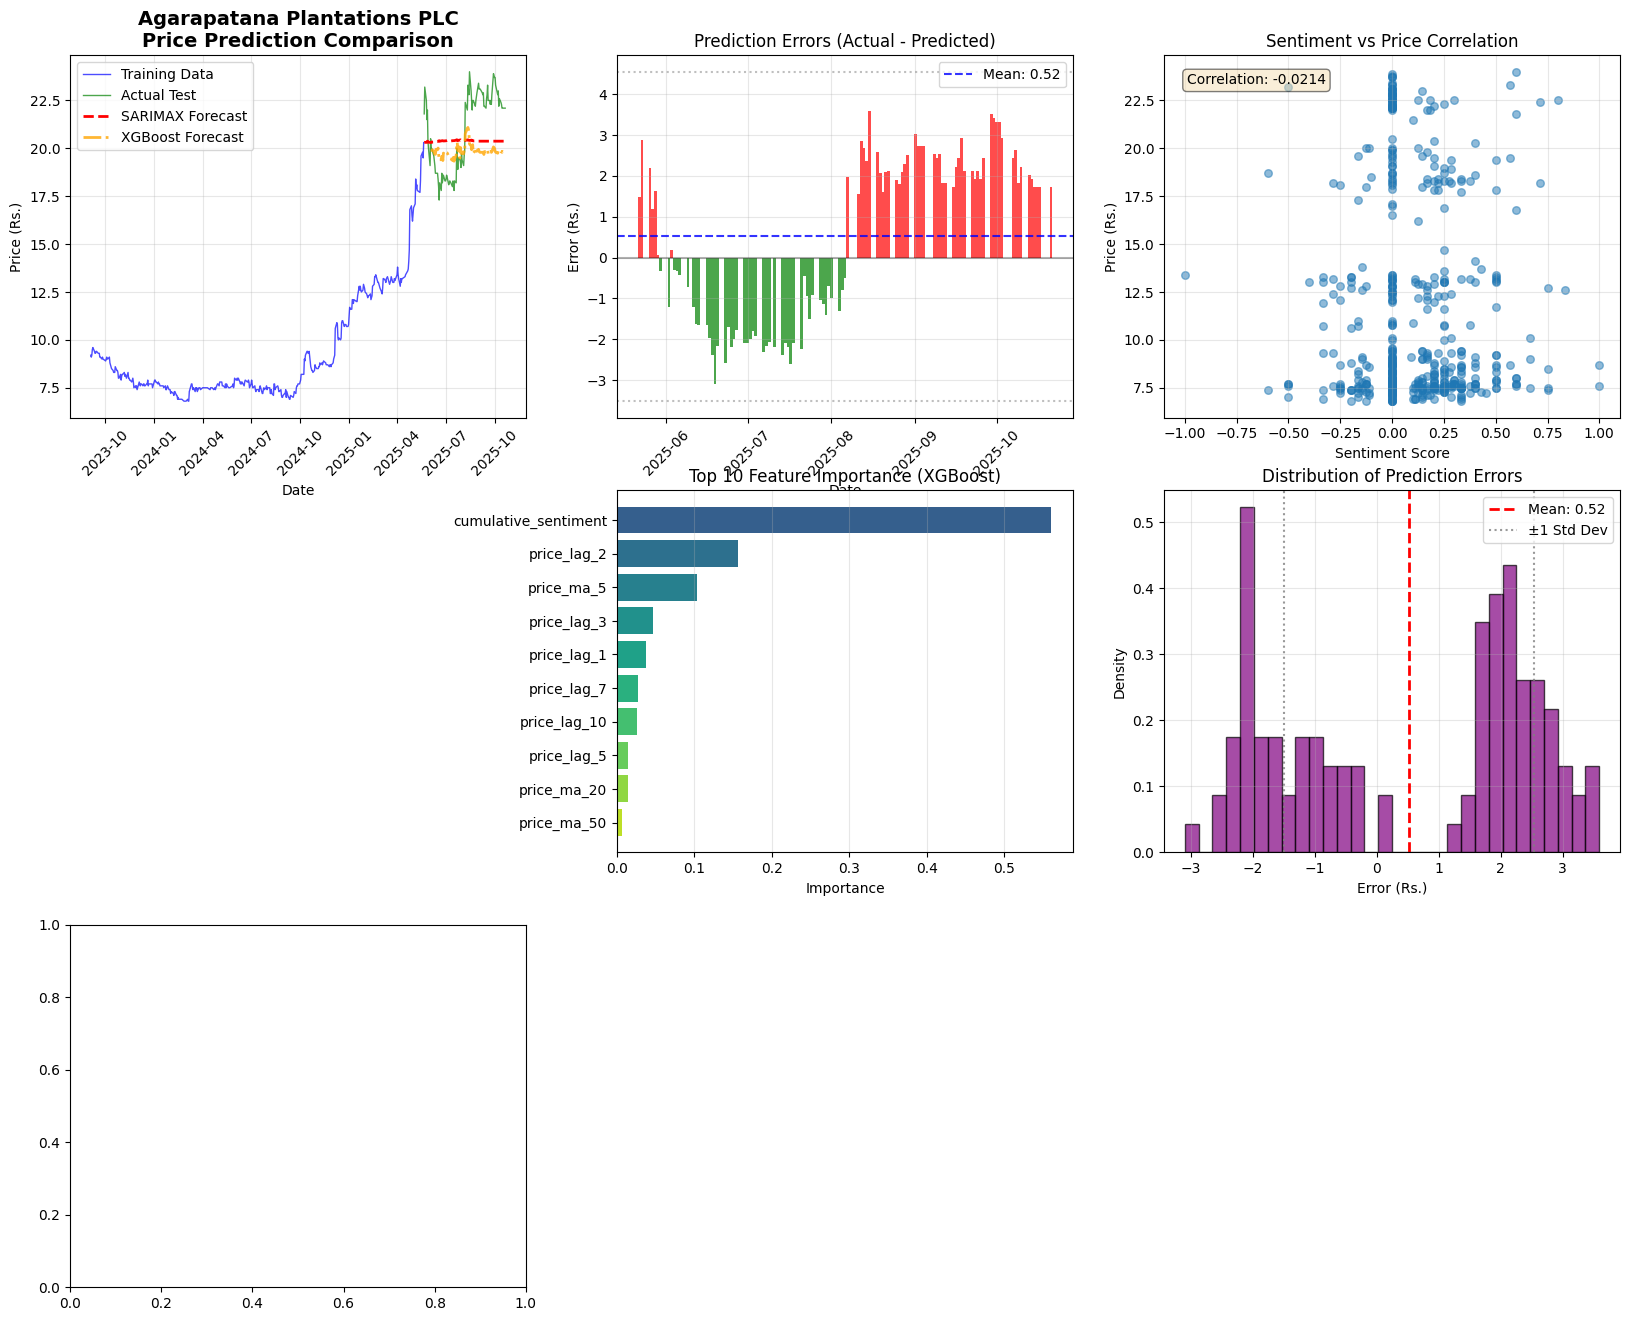

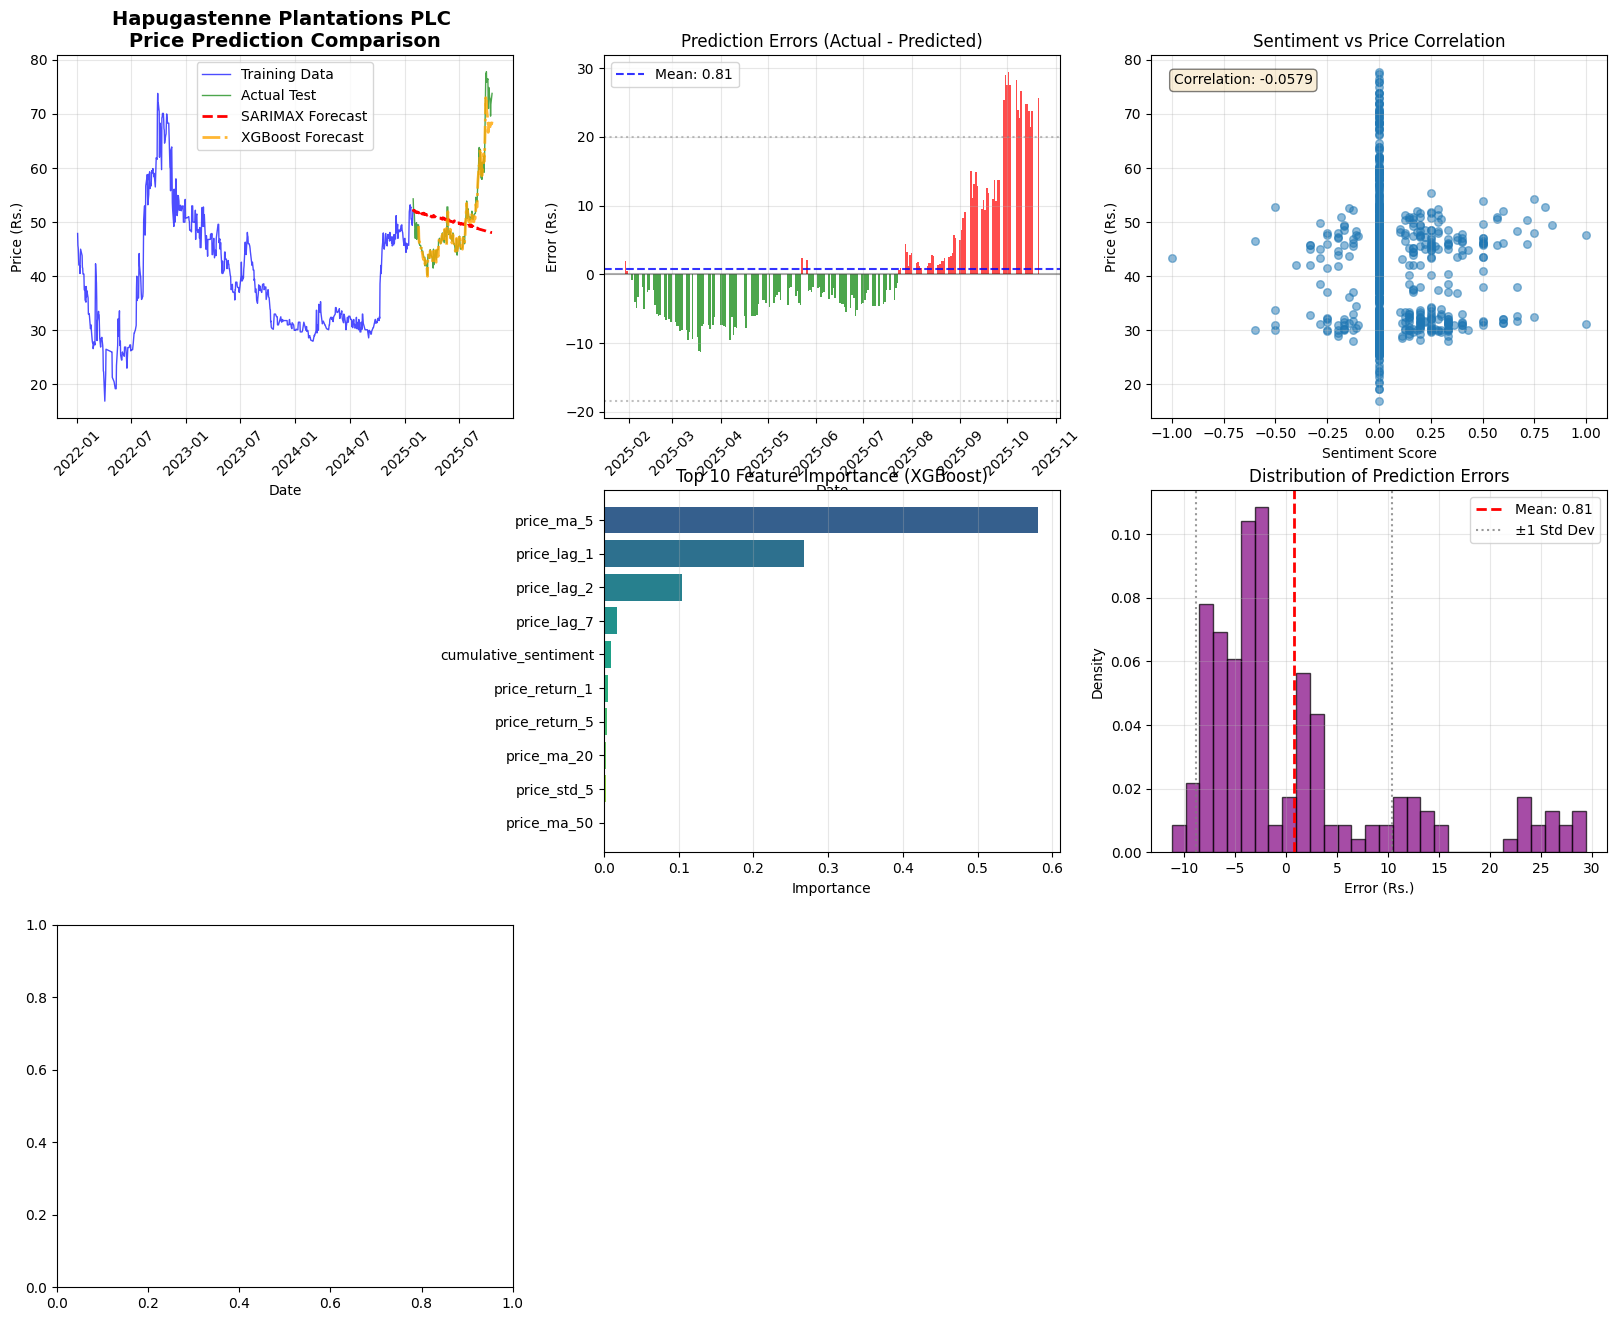

In [5]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# ===============================
# CONFIGURATION
# ===============================

PRICE_DATA_PATH = "./StockData"
SENTIMENT_FILE = "./daily_company_sentiment_scores.xlsx"
PRICE_MODEL_DIR = "price_models_enhanced"
DATASET_DIR = "enhanced_datasets"
os.makedirs(PRICE_MODEL_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

companies = [
    'MCPL.N0000', 'WATA.N0000', 'AGPL.N0000', 'HAPU.N0000',
    'KOTA.N0000', 'BFL.N0000', 'RWSL.N0000', 'DIPP.N0000',
    'MGT.N0000', 'HEXP.N0000'
]

company_names = {
    'MCPL.N0000': 'Mahaweli Coconut Plantations PLC',
    'WATA.N0000': 'Watawala Plantations PLC',
    'AGPL.N0000': 'Agarapatana Plantations PLC',
    'HAPU.N0000': 'Hapugastenne Plantations PLC ',
    'KOTA.N0000': 'Kotagala Plantations PLC',
    'BFL.N0000': 'Bairaha Farms PLC',
    'RWSL.N0000': 'Raigam Wayamba Salterns PLC ',
    'DIPP.N0000': 'Dipped Products PLC',
    'MGT.N0000': 'Hayleys Fabric PLC',
    'HEXP.N0000': 'Hayleys Fibre PLC'
}

# ===============================
# LOAD SENTIMENT DATA
# ===============================

print("="*70)
print("ENHANCED STOCK PRICE FORECASTING WITH SENTIMENT")
print("="*70)

sentiment_df = pd.read_excel(SENTIMENT_FILE)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df.set_index('date', inplace=True)

print(f"✓ Sentiment data loaded: {len(sentiment_df)} days")
print(f"✓ Sentiment columns: {[col for col in sentiment_df.columns if 'sentiment' in col][:5]}...")
print(f"✓ Date range: {sentiment_df.index.min()} to {sentiment_df.index.max()}\n")

# ===============================
# HELPER FUNCTIONS
# ===============================

def check_data_quality(df, company, sentiment_col):
    """
    Check for data issues before modeling
    """
    print(f"🔍 Checking data quality for {company}...")
    
    issues = []
    
    # Check for extreme values
    price_mean = df['Close (Rs.)'].mean()
    price_std = df['Close (Rs.)'].std()
    price_range = df['Close (Rs.)'].max() - df['Close (Rs.)'].min()
    
    if price_range > price_mean * 5:
        issues.append(f"High price volatility: Range = {price_range:.2f} (Mean = {price_mean:.2f})")
    
    # Check for outliers
    outlier_threshold = price_mean + 3 * price_std
    outliers = df[df['Close (Rs.)'] > outlier_threshold]
    if len(outliers) > 0:
        issues.append(f"Potential outliers detected: {len(outliers)} days > {outlier_threshold:.2f}")
    
    # Check sentiment distribution
    sentiment_non_zero = (df[sentiment_col] != 0).sum()
    sentiment_coverage = sentiment_non_zero / len(df)
    
    if sentiment_coverage < 0.3:
        issues.append(f"Low sentiment coverage: {sentiment_coverage*100:.1f}% non-zero days")
    
    # Check for missing values
    missing_price = df['Close (Rs.)'].isnull().sum()
    missing_sentiment = df[sentiment_col].isnull().sum()
    
    if missing_price > 0:
        issues.append(f"Missing price values: {missing_price} days")
    if missing_sentiment > 0:
        issues.append(f"Missing sentiment values: {missing_sentiment} days")
    
    return issues

def enhance_sentiment_features(df, sentiment_col):
    """
    Create better sentiment features
    """
    df_enhanced = df.copy()
    
    # 1. Sentiment momentum (rolling average)
    windows = [3, 5, 7, 10]
    for window in windows:
        df_enhanced[f'sentiment_ma_{window}'] = df_enhanced[sentiment_col].rolling(window=window).mean()
        df_enhanced[f'sentiment_std_{window}'] = df_enhanced[sentiment_col].rolling(window=window).std()
    
    # 2. Sentiment direction and strength
    df_enhanced['sentiment_direction'] = np.sign(df_enhanced[sentiment_col])
    df_enhanced['sentiment_abs'] = np.abs(df_enhanced[sentiment_col])
    
    # 3. Cumulative sentiment
    df_enhanced['cumulative_sentiment'] = df_enhanced[sentiment_col].cumsum()
    
    # 4. Binary sentiment indicators
    df_enhanced['positive_sentiment'] = (df_enhanced[sentiment_col] > 0).astype(int)
    df_enhanced['negative_sentiment'] = (df_enhanced[sentiment_col] < 0).astype(int)
    df_enhanced['neutral_sentiment'] = (df_enhanced[sentiment_col] == 0).astype(int)
    
    # 5. Sentiment changes
    df_enhanced['sentiment_change'] = df_enhanced[sentiment_col].diff()
    df_enhanced['sentiment_change_abs'] = np.abs(df_enhanced['sentiment_change'])
    
    # 6. Lagged sentiment
    lags = [1, 2, 3, 5]
    for lag in lags:
        df_enhanced[f'sentiment_lag_{lag}'] = df_enhanced[sentiment_col].shift(lag)
    
    # Fill NaN values
    df_enhanced = df_enhanced.fillna(0)
    
    return df_enhanced

def prepare_data_transformations(df, company, sentiment_col):
    """
    Prepare data with appropriate transformations
    """
    df_transformed = df.copy()
    
    # Check if log transformation is needed
    price_series = df_transformed['Close (Rs.)']
    price_cv = price_series.std() / price_series.mean()  # Coefficient of variation
    
    if price_cv > 0.3 or company in ['WATA.N0000', 'BFL.N0000']:
        print(f"  ⚠️  High volatility detected (CV: {price_cv:.3f}). Applying log transformation.")
        df_transformed['price_log'] = np.log(price_series)
        target_col = 'price_log'
        use_log = True
    else:
        target_col = 'Close (Rs.)'
        use_log = False
    
    # Check stationarity (simple heuristic)
    price_diff = price_series.diff().dropna()
    if price_diff.std() > price_series.std() * 0.8:
        print(f"  ⚠️  Non-stationary series detected. Applying differencing.")
        if use_log:
            df_transformed['price_stationary'] = df_transformed[target_col].diff()
        else:
            df_transformed['price_stationary'] = price_series.diff()
        target_col = 'price_stationary'
        use_diff = True
    else:
        use_diff = False
    
    # Drop NaN from transformations
    df_transformed = df_transformed.dropna()
    
    return df_transformed, target_col, use_log, use_diff

def enhanced_grid_search(train_data, exog_data, target_col, company):
    """
    Enhanced parameter search with cross-validation
    """
    print(f"  Performing enhanced grid search for {company}...")
    
    best_score = np.inf
    best_params = {}
    
    # Company-specific parameter ranges based on volatility
    volatility_groups = {
        'high': ['WATA.N0000', 'BFL.N0000'],
        'medium': ['MCPL.N0000', 'HAPU.N0000', 'HEXP.N0000'],
        'low': ['AGPL.N0000', 'KOTA.N0000', 'RWSL.N0000', 'DIPP.N0000', 'MGT.N0000']
    }
    
    # Determine volatility group
    volatility = 'medium'
    for vol, companies_list in volatility_groups.items():
        if company in companies_list:
            volatility = vol
            break
    
    # Set parameter ranges based on volatility
    if volatility == 'high':
        p_range = [0, 1]
        d_range = [1, 2]
        q_range = [0, 1]
        P_range = [0]
        D_range = [0, 1]
        Q_range = [0]
        seasonal_periods = [5, 10]
    elif volatility == 'medium':
        p_range = [0, 1, 2]
        d_range = [0, 1]
        q_range = [0, 1, 2]
        P_range = [0, 1]
        D_range = [0, 1]
        Q_range = [0, 1]
        seasonal_periods = [5, 7, 10]
    else:  # low volatility
        p_range = [0, 1, 2]
        d_range = [0, 1]
        q_range = [0, 1, 2]
        P_range = [0, 1]
        D_range = [0]
        Q_range = [0, 1]
        seasonal_periods = [5, 7, 20]
    
    tscv = TimeSeriesSplit(n_splits=3)
    param_combinations = []
    
    for seasonal_period in seasonal_periods:
        for p in p_range:
            for d in d_range:
                for q in q_range:
                    for P in P_range:
                        for D in D_range:
                            for Q in Q_range:
                                try:
                                    cv_scores = []
                                    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data)):
                                        cv_train = train_data.iloc[train_idx]
                                        cv_val = train_data.iloc[val_idx]
                                        
                                        cv_exog_train = exog_data.iloc[train_idx] if exog_data is not None else None
                                        cv_exog_val = exog_data.iloc[val_idx] if exog_data is not None else None
                                        
                                        model = SARIMAX(
                                            cv_train[target_col],
                                            exog=cv_exog_train,
                                            order=(p, d, q),
                                            seasonal_order=(P, D, Q, seasonal_period),
                                            enforce_stationarity=False,
                                            enforce_invertibility=False,
                                            simple_differencing=False
                                        )
                                        fitted = model.fit(disp=False, maxiter=200)
                                        
                                        # Forecast
                                        forecast = fitted.forecast(
                                            steps=len(cv_val),
                                            exog=cv_exog_val
                                        )
                                        
                                        # Calculate MAPE
                                        epsilon = 1e-8
                                        mape = np.mean(
                                            np.abs((cv_val[target_col].values - forecast.values) / 
                                                  (cv_val[target_col].values + epsilon))
                                        ) * 100
                                        cv_scores.append(mape)
                                    
                                    avg_score = np.mean(cv_scores)
                                    std_score = np.std(cv_scores)
                                    
                                    param_combinations.append({
                                        'order': (p, d, q),
                                        'seasonal': (P, D, Q, seasonal_period),
                                        'score': avg_score,
                                        'score_std': std_score,
                                        'seasonal_period': seasonal_period
                                    })
                                    
                                    if avg_score < best_score:
                                        best_score = avg_score
                                        best_params = {
                                            'order': (p, d, q),
                                            'seasonal': (P, D, Q, seasonal_period),
                                            'score': avg_score,
                                            'score_std': std_score
                                        }
                                        
                                except Exception as e:
                                    continue
    
    # Sort and save parameter combinations
    param_df = pd.DataFrame(param_combinations)
    param_df = param_df.sort_values('score').head(20)
    
    print(f"  ✓ Best parameters: {best_params['order']} {best_params['seasonal']}")
    print(f"  ✓ Best CV MAPE: {best_params['score']:.2f}%")
    
    return best_params, param_df

def train_xgboost_model(df, company, sentiment_col, target_col='Close (Rs.)'):
    """
    Train XGBoost model for comparison
    """
    print(f"  Training XGBoost model for {company}...")
    
    # Create enhanced features
    df_enhanced = enhance_sentiment_features(df, sentiment_col)
    
    # Create lagged price features
    for lag in [1, 2, 3, 5, 7, 10, 20]:
        df_enhanced[f'price_lag_{lag}'] = df_enhanced[target_col].shift(lag)
    
    # Technical indicators
    df_enhanced['price_ma_5'] = df_enhanced[target_col].rolling(window=5).mean()
    df_enhanced['price_ma_20'] = df_enhanced[target_col].rolling(window=20).mean()
    df_enhanced['price_ma_50'] = df_enhanced[target_col].rolling(window=50).mean()
    df_enhanced['price_std_5'] = df_enhanced[target_col].rolling(window=5).std()
    df_enhanced['price_std_20'] = df_enhanced[target_col].rolling(window=20).std()
    df_enhanced['price_return_1'] = df_enhanced[target_col].pct_change(1)
    df_enhanced['price_return_5'] = df_enhanced[target_col].pct_change(5)
    
    # Drop NaN values from feature creation
    df_enhanced = df_enhanced.dropna()
    
    # Define features and target
    feature_cols = [col for col in df_enhanced.columns 
                   if col not in [target_col, 'price_log', 'price_stationary'] 
                   and not col.startswith('Unnamed')]
    
    X = df_enhanced[feature_cols]
    y = df_enhanced[target_col]
    
    # Train/test split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train XGBoost with hyperparameter tuning
    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = xgb_model.predict(X_test_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    epsilon = 1e-8
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    # Get the test dates that correspond to predictions
    test_dates = X_test.index
    
    return {
        'model': xgb_model,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'feature_importance': feature_importance,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'test_dates': test_dates
    }

def create_comprehensive_visualizations(company, company_name, df, train, test, 
                                       forecast, xgb_results=None, 
                                       model_info=None, exog_cols=None):
    """
    Create comprehensive visualizations
    """
    print(f"  Creating visualizations for {company}...")
    
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Price and Forecast
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(train.index, train['Close (Rs.)'], label="Training Data", color='blue', alpha=0.7, linewidth=1)
    ax1.plot(test.index, test['Close (Rs.)'], label="Actual Test", color='green', alpha=0.7, linewidth=1)
    
    # Plot SARIMAX forecast if available
    if forecast is not None and len(forecast) > 0:
        # Ensure forecast has the same index as test
        if len(forecast) == len(test):
            forecast_index = test.index
        else:
            forecast_index = test.index[:len(forecast)]
        ax1.plot(forecast_index, forecast, label="SARIMAX Forecast", color='red', linestyle="--", linewidth=2)
    
    if xgb_results is not None:
        # Align XGBoost predictions with test dates
        xgb_pred_aligned = pd.Series(xgb_results['y_pred'], index=xgb_results['test_dates'])
        # Filter to only include dates in test set
        xgb_pred_aligned = xgb_pred_aligned[xgb_pred_aligned.index.isin(test.index)]
        if len(xgb_pred_aligned) > 0:
            ax1.plot(xgb_pred_aligned.index, xgb_pred_aligned.values, label="XGBoost Forecast", 
                    color='orange', linestyle="-.", linewidth=2, alpha=0.8)
    
    ax1.set_title(f'{company_name}\nPrice Prediction Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (Rs.)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Prediction Errors
    ax2 = plt.subplot(3, 3, 2)
    if forecast is not None and len(forecast) > 0:
        # Align forecast with test
        if len(forecast) == len(test):
            forecast_aligned = forecast
            test_aligned = test['Close (Rs.)'].values
        else:
            forecast_aligned = forecast[:min(len(forecast), len(test))]
            test_aligned = test['Close (Rs.)'].iloc[:len(forecast_aligned)].values
        
        errors = test_aligned - forecast_aligned
        error_dates = test.index[:len(errors)]
        
        ax2.bar(error_dates, errors, 
               color=np.where(errors >= 0, 'red', 'green'), 
               alpha=0.7, width=1)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax2.axhline(y=errors.mean(), color='blue', linestyle='--', alpha=0.8, label=f'Mean: {errors.mean():.2f}')
        ax2.axhline(y=errors.mean() + 2*errors.std(), color='gray', linestyle=':', alpha=0.5)
        ax2.axhline(y=errors.mean() - 2*errors.std(), color='gray', linestyle=':', alpha=0.5)
        ax2.set_title('Prediction Errors (Actual - Predicted)', fontsize=12)
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Error (Rs.)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.text(0.5, 0.5, 'No SARIMAX\nForecast Available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Prediction Errors (Actual - Predicted)', fontsize=12)
    
    # 3. Sentiment vs Price
    ax3 = plt.subplot(3, 3, 3)
    if exog_cols and len(exog_cols) > 0:
        scatter_x = df[exog_cols[0]]
    else:
        # Use the last sentiment column
        sentiment_cols = [col for col in df.columns if 'sentiment' in col]
        if sentiment_cols:
            scatter_x = df[sentiment_cols[0]]
        else:
            scatter_x = df.iloc[:, -1]
    
    scatter = ax3.scatter(scatter_x, df['Close (Rs.)'], 
                         alpha=0.5, cmap='viridis', s=30)
    ax3.set_title('Sentiment vs Price Correlation', fontsize=12)
    ax3.set_xlabel('Sentiment Score')
    ax3.set_ylabel('Price (Rs.)')
    ax3.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    correlation = df['Close (Rs.)'].corr(scatter_x)
    ax3.text(0.05, 0.95, f'Correlation: {correlation:.4f}',
            transform=ax3.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4. Model Residuals
    if model_info and 'model' in model_info and hasattr(model_info['model'], 'resid'):
        ax4 = plt.subplot(3, 3, 4)
        residuals = model_info['model'].resid
        ax4.plot(residuals.index, residuals, color='orange', alpha=0.7, linewidth=1)
        ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax4.axhline(y=residuals.mean() + 2*residuals.std(), color='gray', linestyle=':', alpha=0.5)
        ax4.axhline(y=residuals.mean() - 2*residuals.std(), color='gray', linestyle=':', alpha=0.5)
        ax4.fill_between(residuals.index, 
                        residuals.mean() - 2*residuals.std(),
                        residuals.mean() + 2*residuals.std(),
                        alpha=0.2, color='gray')
        ax4.set_title('Model Residuals', fontsize=12)
        ax4.set_xlabel('Date')
        ax4.set_ylabel('Residual')
        ax4.grid(True, alpha=0.3)
        ax4.tick_params(axis='x', rotation=45)
    
    # 5. Feature Importance (XGBoost)
    if xgb_results is not None:
        ax5 = plt.subplot(3, 3, 5)
        importance_df = xgb_results['feature_importance'].head(10)
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
        ax5.barh(range(len(importance_df)), importance_df['importance'], color=colors)
        ax5.set_yticks(range(len(importance_df)))
        ax5.set_yticklabels(importance_df['feature'])
        ax5.set_title('Top 10 Feature Importance (XGBoost)', fontsize=12)
        ax5.set_xlabel('Importance')
        ax5.invert_yaxis()
        ax5.grid(True, alpha=0.3, axis='x')
    
    # 6. Histogram of Prediction Errors
    ax6 = plt.subplot(3, 3, 6)
    if forecast is not None and len(forecast) > 0 and 'errors' in locals():
        ax6.hist(errors, bins=30, color='purple', alpha=0.7, edgecolor='black', density=True)
        ax6.axvline(x=errors.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {errors.mean():.2f}')
        ax6.axvline(x=errors.mean() + errors.std(), color='gray', linestyle=':', 
                   alpha=0.8, label=f'±1 Std Dev')
        ax6.axvline(x=errors.mean() - errors.std(), color='gray', linestyle=':', 
                   alpha=0.8)
        ax6.set_title('Distribution of Prediction Errors', fontsize=12)
        ax6.set_xlabel('Error (Rs.)')
        ax6.set_ylabel('Density')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    else:
        ax6.text(0.5, 0.5, 'No Error\nData Available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax6.transAxes, fontsize=12)
        ax6.set_title('Distribution of Prediction Errors', fontsize=12)
    
    # 7. Cumulative Returns
    ax7 = plt.subplot(3, 3, 7)
    if forecast is not None and len(forecast) > 0:
        # Align forecast with test
        if len(forecast) == len(test):
            forecast_aligned = forecast
            test_aligned = test['Close (Rs.)']
        else:
            forecast_aligned = pd.Series(forecast[:min(len(forecast), len(test))], 
                                        index=test.index[:min(len(forecast), len(test))])
            test_aligned = test['Close (Rs.)'].iloc[:len(forecast_aligned)]
        
        actual_returns = test_aligned.pct_change().fillna(0).cumsum()
        predicted_returns = forecast_aligned.pct_change().fillna(0).cumsum()
        
        ax7.plot(test_aligned.index, actual_returns, label='Actual Returns', color='green', linewidth=2)
        ax7.plot(test_aligned.index, predicted_returns, label='Predicted Returns', color='red', linestyle='--', linewidth=2)
        ax7.set_title('Cumulative Returns Comparison', fontsize=12)
        ax7.set_xlabel('Date')
        ax7.set_ylabel('Cumulative Return')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
        ax7.tick_params(axis='x', rotation=45)
    else:
        ax7.text(0.5, 0.5, 'No Forecast\nData Available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax7.transAxes, fontsize=12)
        ax7.set_title('Cumulative Returns Comparison', fontsize=12)
    
    # 8. QQ-Plot of Residuals
    if model_info and 'model' in model_info and hasattr(model_info['model'], 'resid'):
        ax8 = plt.subplot(3, 3, 8)
        try:
            from scipy import stats
            residuals = model_info['model'].resid
            stats.probplot(residuals, dist="norm", plot=ax8)
            ax8.set_title('Q-Q Plot of Residuals', fontsize=12)
            ax8.grid(True, alpha=0.3)
        except:
            ax8.text(0.5, 0.5, 'Q-Q Plot\nNot Available', 
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax8.transAxes, fontsize=12)
            ax8.set_title('Q-Q Plot of Residuals', fontsize=12)
    
    # 9. Performance Metrics Summary
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    
    metrics_text = f"PERFORMANCE METRICS\n"
    metrics_text += "="*30 + "\n"
    
    if model_info and 'performance_metrics' in model_info:
        metrics = model_info['performance_metrics']
        metrics_text += f"SARIMAX:\n"
        metrics_text += f"  MAE:  Rs. {metrics['mae']:.2f}\n"
        metrics_text += f"  RMSE: Rs. {metrics['rmse']:.2f}\n"
        metrics_text += f"  MAPE: {metrics['mape']:.2f}%\n\n"
    
    if xgb_results:
        metrics_text += f"XGBoost:\n"
        metrics_text += f"  MAE:  Rs. {xgb_results['mae']:.2f}\n"
        metrics_text += f"  RMSE: Rs. {xgb_results['rmse']:.2f}\n"
        metrics_text += f"  MAPE: {xgb_results['mape']:.2f}%\n\n"
    
    metrics_text += f"Parameters:\n"
    if model_info and 'order' in model_info:
        metrics_text += f"  Order: {model_info['order']}\n"
        metrics_text += f"  Seasonal: {model_info['seasonal_order']}\n"
    
    ax9.text(0.1, 0.5, metrics_text, fontsize=10, 
            verticalalignment='center', fontfamily='monospace')
    
    plt.tight_layout()
    plot_path = f"{PRICE_MODEL_DIR}/{company}_comprehensive_analysis.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ Comprehensive analysis plot saved: {plot_path}")
    return plot_path

def save_model_with_metadata(model_info, model_path):
    """
    Save model with comprehensive metadata
    """
    # Add timestamp
    model_info['training_timestamp'] = pd.Timestamp.now()
    model_info['model_version'] = '2.0_enhanced'
    
    # Save model
    joblib.dump(model_info, model_path)
    
    # Save metadata separately - handle complex objects
    metadata = {}
    for key, value in model_info.items():
        if key == 'model':
            # Skip the main model object - it's saved in joblib
            continue
        elif key in ['sarimax_model_info', 'xgb_model_info'] and value is not None:
            # Handle nested model info in ensemble
            if key == 'sarimax_model_info' and 'model' in value:
                # Extract only metadata from SARIMAX model
                sarimax_metadata = {}
                for sub_key, sub_value in value.items():
                    if sub_key != 'model':  # Skip the actual model
                        if isinstance(sub_value, (pd.Timestamp, pd.DatetimeIndex, pd.Index)):
                            sarimax_metadata[sub_key] = str(sub_value)
                        elif isinstance(sub_value, np.integer):
                            sarimax_metadata[sub_key] = int(sub_value)
                        elif isinstance(sub_value, np.floating):
                            sarimax_metadata[sub_key] = float(sub_value)
                        elif isinstance(sub_value, np.ndarray):
                            sarimax_metadata[sub_key] = sub_value.tolist()
                        else:
                            sarimax_metadata[sub_key] = sub_value
                metadata[key] = sarimax_metadata
            elif key == 'xgb_model_info' and 'model' in value:
                # Extract only metadata from XGBoost model
                xgb_metadata = {}
                for sub_key, sub_value in value.items():
                    if sub_key not in ['model', 'scaler']:  # Skip actual model and scaler
                        if isinstance(sub_value, (pd.Timestamp, pd.DatetimeIndex, pd.Index)):
                            xgb_metadata[sub_key] = str(sub_value)
                        elif isinstance(sub_value, np.integer):
                            xgb_metadata[sub_key] = int(sub_value)
                        elif isinstance(sub_value, np.floating):
                            xgb_metadata[sub_key] = float(sub_value)
                        elif isinstance(sub_value, np.ndarray):
                            xgb_metadata[sub_key] = sub_value.tolist()
                        else:
                            xgb_metadata[sub_key] = sub_value
                metadata[key] = xgb_metadata
            else:
                metadata[key] = value
        elif isinstance(value, (pd.Timestamp, pd.DatetimeIndex, pd.Index)):
            metadata[key] = str(value)
        elif isinstance(value, np.integer):
            metadata[key] = int(value)
        elif isinstance(value, np.floating):
            metadata[key] = float(value)
        elif isinstance(value, np.ndarray):
            metadata[key] = value.tolist()
        elif hasattr(value, '__dict__'):
            # Skip complex objects that can't be serialized
            continue
        else:
            metadata[key] = value
    
    metadata_path = model_path.replace('.joblib', '_metadata.json')
    
    import json
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    return metadata_path

def retrain_ensemble_model(df, company, sentiment_col, sarimax_params, 
                          sarimax_mape, xgb_results, xgb_mape, ensemble_weights):
    """
    Retrain ensemble model on full dataset
    """
    print(f"  Retraining ensemble model for {company}...")
    
    # Prepare data for SARIMAX
    df_enhanced = enhance_sentiment_features(df, sentiment_col)
    sentiment_features = [col for col in df_enhanced.columns if 'sentiment' in col]
    top_sentiment_features = sentiment_features[:3] if len(sentiment_features) >= 3 else sentiment_features
    
    # Retrain SARIMAX on full dataset
    sarimax_model_info = None
    if sarimax_params:
        try:
            # Determine target column (check if log was used)
            use_log = False
            if 'price_log' in df_enhanced.columns:
                target_col = 'price_log'
                use_log = True
            else:
                target_col = 'Close (Rs.)'
            
            sarimax_model = SARIMAX(
                df_enhanced[target_col],
                exog=df_enhanced[top_sentiment_features] if len(top_sentiment_features) > 0 else None,
                order=sarimax_params['order'],
                seasonal_order=sarimax_params['seasonal'],
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            sarimax_fitted = sarimax_model.fit(disp=False)
            
            sarimax_model_info = {
                "model": sarimax_fitted,
                "order": sarimax_params['order'],
                "seasonal_order": sarimax_params['seasonal'],
                "sentiment_features": top_sentiment_features,
                "use_log": use_log,
                "target_col": target_col,
                "performance": {
                    "mape": float(sarimax_mape)
                }
            }
        except Exception as e:
            print(f"    ⚠️  SARIMAX retraining failed: {str(e)}")
    
    # Retrain XGBoost on full dataset
    xgb_model_info = None
    if xgb_results:
        try:
            # Prepare full dataset for XGBoost
            df_full_enhanced = enhance_sentiment_features(df, sentiment_col)
            
            # Create features
            for lag in [1, 2, 3, 5, 7, 10, 20]:
                df_full_enhanced[f'price_lag_{lag}'] = df_full_enhanced['Close (Rs.)'].shift(lag)
            
            # Technical indicators
            df_full_enhanced['price_ma_5'] = df_full_enhanced['Close (Rs.)'].rolling(window=5).mean()
            df_full_enhanced['price_ma_20'] = df_full_enhanced['Close (Rs.)'].rolling(window=20).mean()
            df_full_enhanced['price_return_1'] = df_full_enhanced['Close (Rs.)'].pct_change(1)
            
            df_full_enhanced = df_full_enhanced.dropna()
            
            # Define features and target
            feature_cols = [col for col in df_full_enhanced.columns 
                           if col not in ['Close (Rs.)', 'price_log', 'price_stationary'] 
                           and not col.startswith('Unnamed')]
            
            X_full = df_full_enhanced[feature_cols]
            y_full = df_full_enhanced['Close (Rs.)']
            
            # Scale features
            scaler_full = StandardScaler()
            X_full_scaled = scaler_full.fit_transform(X_full)
            
            # Train final model
            final_xgb = XGBRegressor(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
            final_xgb.fit(X_full_scaled, y_full)
            
            xgb_model_info = {
                "model": final_xgb,
                "scaler": scaler_full,
                "feature_cols": feature_cols,
                "performance": {
                    "mape": float(xgb_mape)
                }
            }
        except Exception as e:
            print(f"    ⚠️  XGBoost retraining failed: {str(e)}")
    
    # Create ensemble model info
    ensemble_info = {
        "sarimax_model_info": sarimax_model_info,
        "xgb_model_info": xgb_model_info,
        "ensemble_weights": ensemble_weights,
        "company": company,
        "company_name": company_names.get(company, company),
        "model_type": "Ensemble",
        "training_date": str(pd.Timestamp.now()),
        "dataset_size": len(df)
    }
    
    return ensemble_info

# ===============================
# MAIN TRAINING LOOP
# ===============================

results = []
all_datasets_summary = []

for company in companies:
    print("\n" + "="*70)
    print(f"ENHANCED TRAINING FOR {company_names.get(company, company)}")
    print(f"Company Code: {company}")
    print("="*70)

    # =============================
    # LOAD AND PREPARE DATA
    # =============================
    
    price_file = f"{PRICE_DATA_PATH}/{company.split('.')[0]}.csv"

    if not os.path.exists(price_file):
        print(f"❌ Price file missing: {price_file}")
        continue

    sentiment_col = f"{company}_sentiment_score"
    if sentiment_col not in sentiment_df.columns:
        print(f"❌ Sentiment column missing: {sentiment_col}")
        continue

    # Load price data
    df_price = pd.read_csv(price_file)
    df_price['Trade Date'] = pd.to_datetime(df_price['Trade Date'])
    df_price = df_price.sort_values('Trade Date')
    df_price = df_price[['Trade Date', 'Close (Rs.)']]
    df_price.set_index('Trade Date', inplace=True)

    print(f"✓ Price data loaded: {len(df_price)} days")
    print(f"  Date range: {df_price.index.min()} to {df_price.index.max()}")
    print(f"  Price range: Rs. {df_price['Close (Rs.)'].min():.2f} - Rs. {df_price['Close (Rs.)'].max():.2f}")

    # Merge with sentiment
    df = df_price.join(sentiment_df[[sentiment_col]], how='left')
    df[sentiment_col] = df[sentiment_col].fillna(0)
    df = df.dropna()

    print(f"✓ Merged data: {len(df)} days")
    print(f"  Non-zero sentiment days: {len(df[df[sentiment_col] != 0])}")
    
    # =============================
    # DATA QUALITY CHECK
    # =============================
    
    issues = check_data_quality(df, company, sentiment_col)
    if issues:
        print(f"⚠️  Data quality issues detected:")
        for issue in issues:
            print(f"   • {issue}")
    
    # =============================
    # DATA TRANSFORMATIONS
    # =============================
    
    df_transformed, target_col, use_log, use_diff = prepare_data_transformations(df, company, sentiment_col)
    
    # =============================
    # ENHANCE FEATURES
    # =============================
    
    df_enhanced = enhance_sentiment_features(df_transformed, sentiment_col)
    
    # Select exogenous variables
    sentiment_features = [col for col in df_enhanced.columns if 'sentiment' in col]
    print(f"✓ Created {len(sentiment_features)} sentiment features")
    
    # =============================
    # TRAIN/TEST SPLIT
    # =============================
    
    split_idx = int(len(df_enhanced) * 0.8)
    train = df_enhanced.iloc[:split_idx]
    test = df_enhanced.iloc[split_idx:]
    
    print(f"\n📊 Dataset Split:")
    print(f"  Train size: {len(train)} days ({train.index.min()} to {train.index.max()})")
    print(f"  Test size : {len(test)} days ({test.index.min()} to {test.index.max()})")
    print(f"  Target variable: {target_col}")
    
    # =============================
    # GRID SEARCH FOR SARIMAX
    # =============================
    
    print("\n🔍 Performing enhanced grid search...")
    
    # Use most important sentiment features as exogenous variables
    top_sentiment_features = sentiment_features[:3] if len(sentiment_features) >= 3 else sentiment_features
    
    best_params, param_df = enhanced_grid_search(
        train, 
        train[top_sentiment_features] if len(top_sentiment_features) > 0 else None,
        target_col,
        company
    )
    
    # Save parameter search results
    param_path = f"{PRICE_MODEL_DIR}/{company}_parameter_search_enhanced.csv"
    param_df.to_csv(param_path, index=False)
    print(f"✓ Parameter search results saved: {param_path}")
    
    # =============================
    # TRAIN SARIMAX MODEL
    # =============================
    
    print("\n🏋️ Training SARIMAX model...")
    
    sarimax_success = False
    mae = rmse = mape = np.nan
    forecast = pd.Series(index=test.index)
    sarimax_fitted = None
    
    try:
        # Prepare exogenous data
        exog_data = train[top_sentiment_features] if len(top_sentiment_features) > 0 else None
        exog_test = test[top_sentiment_features] if len(top_sentiment_features) > 0 else None
        
        model = SARIMAX(
            train[target_col],
            exog=exog_data,
            order=best_params['order'],
            seasonal_order=best_params['seasonal'],
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=False
        )
        fitted = model.fit(disp=False, maxiter=200)
        sarimax_fitted = fitted
        
        # Forecast
        forecast_steps = len(test)
        forecast_raw = fitted.forecast(
            steps=forecast_steps,
            exog=exog_test
        )
        
        # Transform back if needed
        if use_log:
            forecast = np.exp(forecast_raw)
            actual_test = np.exp(test[target_col])
        elif use_diff:
            # Reconstruct original series from differenced predictions
            last_train_value = train['Close (Rs.)'].iloc[-1]
            forecast_cumsum = forecast_raw.cumsum()
            forecast = last_train_value + forecast_cumsum
            actual_test = test['Close (Rs.)']
        else:
            forecast = forecast_raw
            actual_test = test[target_col]
        
        # Ensure same length
        min_len = min(len(actual_test), len(forecast))
        actual_test = actual_test.iloc[:min_len]
        forecast = forecast.iloc[:min_len]
        
        # Calculate metrics
        mae = mean_absolute_error(actual_test, forecast)
        rmse = np.sqrt(mean_squared_error(actual_test, forecast))
        epsilon = 1e-8
        mape = np.mean(np.abs((actual_test.values - forecast.values) / (actual_test.values + epsilon))) * 100
        
        print(f"✓ SARIMAX Training Complete")
        print(f"  MAE  : Rs. {mae:.2f}")
        print(f"  RMSE : Rs. {rmse:.2f}")
        print(f"  MAPE : {mape:.2f}%")
        
        sarimax_success = True
        
    except Exception as e:
        print(f"❌ SARIMAX training failed: {str(e)}")
        sarimax_success = False
    
    # =============================
    # TRAIN XGBOOST MODEL
    # =============================
    
    print("\n🌲 Training XGBoost model...")
    
    xgb_success = False
    xgb_results = None
    
    try:
        xgb_results = train_xgboost_model(df_enhanced, company, sentiment_col, 'Close (Rs.)')
        print(f"✓ XGBoost Training Complete")
        print(f"  MAE  : Rs. {xgb_results['mae']:.2f}")
        print(f"  RMSE : Rs. {xgb_results['rmse']:.2f}")
        print(f"  MAPE : {xgb_results['mape']:.2f}%")
        
        # Save feature importance
        feat_imp_path = f"{PRICE_MODEL_DIR}/{company}_feature_importance.csv"
        xgb_results['feature_importance'].to_csv(feat_imp_path, index=False)
        print(f"✓ Feature importance saved: {feat_imp_path}")
        
        xgb_success = True
        
    except Exception as e:
        print(f"⚠️  XGBoost training failed: {str(e)}")
        xgb_results = None
    
    # =============================
    # ENSEMBLE PREDICTIONS
    # =============================
    
    print("\n🤖 Creating ensemble predictions...")
    
    ensemble_pred = None
    ensemble_mape = np.nan
    best_model = None
    ensemble_weights = None
    
    if sarimax_success and xgb_success:
        # Weighted ensemble based on MAPE
        sarimax_weight = 1 / mape if mape > 0 else 0
        xgb_weight = 1 / xgb_results['mape'] if xgb_results['mape'] > 0 else 0
        total_weight = sarimax_weight + xgb_weight
        
        if total_weight > 0:
            sarimax_weight /= total_weight
            xgb_weight /= total_weight
            ensemble_weights = {'sarimax': float(sarimax_weight), 'xgboost': float(xgb_weight)}
            
            # Align predictions
            # Create aligned series for SARIMAX
            sarimax_pred_series = pd.Series(forecast.values, index=test.index[:len(forecast)])
            
            # Create aligned series for XGBoost
            xgb_pred_series = pd.Series(xgb_results['y_pred'], index=xgb_results['test_dates'])
            
            # Find common dates
            common_dates = sarimax_pred_series.index.intersection(xgb_pred_series.index)
            
            if len(common_dates) > 0:
                sarimax_aligned = sarimax_pred_series.loc[common_dates].values
                xgb_pred_aligned = xgb_pred_series.loc[common_dates].values
                test_aligned = test.loc[common_dates, 'Close (Rs.)'].values
                
                ensemble_pred = sarimax_weight * sarimax_aligned + xgb_weight * xgb_pred_aligned
                
                # Calculate ensemble metrics
                ensemble_mae = mean_absolute_error(test_aligned, ensemble_pred)
                ensemble_rmse = np.sqrt(mean_squared_error(test_aligned, ensemble_pred))
                epsilon = 1e-8
                ensemble_mape = np.mean(np.abs((test_aligned - ensemble_pred) / (test_aligned + epsilon))) * 100
                
                print(f"✓ Ensemble created (weights: SARIMAX={sarimax_weight:.2f}, XGBoost={xgb_weight:.2f})")
                print(f"  Ensemble MAE : Rs. {ensemble_mae:.2f}")
                print(f"  Ensemble RMSE: Rs. {ensemble_rmse:.2f}")
                print(f"  Ensemble MAPE: {ensemble_mape:.2f}%")
                
                # Determine best model
                model_performance = {
                    'SARIMAX': mape,
                    'XGBoost': xgb_results['mape'],
                    'Ensemble': ensemble_mape
                }
                best_model = min(model_performance, key=model_performance.get)
            else:
                print("⚠️  No common dates for ensemble. Using individual models.")
                best_model = 'SARIMAX' if mape < xgb_results['mape'] else 'XGBoost'
        else:
            best_model = 'SARIMAX' if mape < xgb_results['mape'] else 'XGBoost'
    elif sarimax_success:
        best_model = 'SARIMAX'
    elif xgb_success:
        best_model = 'XGBoost'
    else:
        print(f"❌ No valid models for {company}")
        continue
    
    print(f"  Best model selected: {best_model}")
    
    # =============================
    # RETRAIN FINAL MODEL
    # =============================
    
    print(f"\n🔄 Retraining final {best_model} model on complete dataset...")
    
    model_info = None
    
    if best_model == 'SARIMAX' and sarimax_success:
        # Retrain SARIMAX on full dataset
        try:
            final_model = SARIMAX(
                df_enhanced[target_col],
                exog=df_enhanced[top_sentiment_features] if len(top_sentiment_features) > 0 else None,
                order=best_params['order'],
                seasonal_order=best_params['seasonal'],
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            final_fitted = final_model.fit(disp=False)
            
            model_info = {
                "model": final_fitted,
                "company": company,
                "company_name": company_names.get(company, company),
                "order": best_params['order'],
                "seasonal_order": best_params['seasonal'],
                "sentiment_features": top_sentiment_features,
                "use_log": use_log,
                "use_diff": use_diff,
                "target_col": target_col,
                "last_price": float(df['Close (Rs.)'].iloc[-1]),
                "last_date": str(df.index[-1]),
                "model_type": "SARIMAX",
                "training_date": str(pd.Timestamp.now()),
                "dataset_size": len(df),
                "performance_metrics": {
                    "mae": float(mae),
                    "rmse": float(rmse),
                    "mape": float(mape)
                },
                "cv_performance": {
                    "cv_mape": float(best_params['score']),
                    "cv_std": float(best_params['score_std'])
                }
            }
        except Exception as e:
            print(f"❌ Error retraining SARIMAX: {str(e)}")
    
    elif best_model == 'XGBoost' and xgb_success:
        # Retrain XGBoost on full dataset
        try:
            # Prepare full dataset for XGBoost
            df_full_enhanced = enhance_sentiment_features(df, sentiment_col)
            
            # Create features
            for lag in [1, 2, 3, 5, 7, 10, 20]:
                df_full_enhanced[f'price_lag_{lag}'] = df_full_enhanced['Close (Rs.)'].shift(lag)
            
            # Technical indicators
            df_full_enhanced['price_ma_5'] = df_full_enhanced['Close (Rs.)'].rolling(window=5).mean()
            df_full_enhanced['price_ma_20'] = df_full_enhanced['Close (Rs.)'].rolling(window=20).mean()
            df_full_enhanced['price_return_1'] = df_full_enhanced['Close (Rs.)'].pct_change(1)
            
            df_full_enhanced = df_full_enhanced.dropna()
            
            # Define features and target
            feature_cols = [col for col in df_full_enhanced.columns 
                           if col not in ['Close (Rs.)', 'price_log', 'price_stationary'] 
                           and not col.startswith('Unnamed')]
            
            X_full = df_full_enhanced[feature_cols]
            y_full = df_full_enhanced['Close (Rs.)']
            
            # Scale features
            scaler_full = StandardScaler()
            X_full_scaled = scaler_full.fit_transform(X_full)
            
            # Train final model
            final_xgb = XGBRegressor(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
            final_xgb.fit(X_full_scaled, y_full)
            
            model_info = {
                "model": final_xgb,
                "scaler": scaler_full,
                "feature_cols": feature_cols,
                "company": company,
                "company_name": company_names.get(company, company),
                "model_type": "XGBoost",
                "training_date": str(pd.Timestamp.now()),
                "dataset_size": len(df),
                "performance_metrics": {
                    "mae": float(xgb_results['mae']),
                    "rmse": float(xgb_results['rmse']),
                    "mape": float(xgb_results['mape'])
                }
            }
        except Exception as e:
            print(f"❌ Error retraining XGBoost: {str(e)}")
    
    elif best_model == 'Ensemble' and sarimax_success and xgb_success:
        # Retrain Ensemble model on full dataset
        try:
            model_info = retrain_ensemble_model(
                df, company, sentiment_col, 
                best_params, mape, 
                xgb_results, xgb_results['mape'],
                ensemble_weights
            )
        except Exception as e:
            print(f"❌ Error retraining Ensemble: {str(e)}")
            # Fall back to XGBoost if Ensemble fails (which has better MAPE than SARIMAX)
            best_model = 'XGBoost'
            print(f"  Falling back to {best_model} model")
            
            # Retry with XGBoost
            try:
                # Prepare full dataset for XGBoost
                df_full_enhanced = enhance_sentiment_features(df, sentiment_col)
                
                # Create features
                for lag in [1, 2, 3, 5, 7, 10, 20]:
                    df_full_enhanced[f'price_lag_{lag}'] = df_full_enhanced['Close (Rs.)'].shift(lag)
                
                # Technical indicators
                df_full_enhanced['price_ma_5'] = df_full_enhanced['Close (Rs.)'].rolling(window=5).mean()
                df_full_enhanced['price_ma_20'] = df_full_enhanced['Close (Rs.)'].rolling(window=20).mean()
                df_full_enhanced['price_return_1'] = df_full_enhanced['Close (Rs.)'].pct_change(1)
                
                df_full_enhanced = df_full_enhanced.dropna()
                
                # Define features and target
                feature_cols = [col for col in df_full_enhanced.columns 
                               if col not in ['Close (Rs.)', 'price_log', 'price_stationary'] 
                               and not col.startswith('Unnamed')]
                
                X_full = df_full_enhanced[feature_cols]
                y_full = df_full_enhanced['Close (Rs.)']
                
                # Scale features
                scaler_full = StandardScaler()
                X_full_scaled = scaler_full.fit_transform(X_full)
                
                # Train final model
                final_xgb = XGBRegressor(
                    n_estimators=200,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    n_jobs=-1
                )
                final_xgb.fit(X_full_scaled, y_full)
                
                model_info = {
                    "model": final_xgb,
                    "scaler": scaler_full,
                    "feature_cols": feature_cols,
                    "company": company,
                    "company_name": company_names.get(company, company),
                    "model_type": "XGBoost",
                    "training_date": str(pd.Timestamp.now()),
                    "dataset_size": len(df),
                    "performance_metrics": {
                        "mae": float(xgb_results['mae']),
                        "rmse": float(xgb_results['rmse']),
                        "mape": float(xgb_results['mape'])
                    }
                }
            except Exception as e2:
                print(f"❌ Error retraining fallback XGBoost: {str(e2)}")
                model_info = None
    
    if model_info is None:
        print(f"❌ Failed to create final model for {company}")
        continue
    
    # =============================
    # SAVE MODELS
    # =============================
    
    model_path = f"{PRICE_MODEL_DIR}/{company}_{best_model.lower()}.joblib"
    metadata_path = save_model_with_metadata(model_info, model_path)
    
    print(f"✅ Model saved: {model_path}")
    print(f"✅ Metadata saved: {metadata_path}")
    
    # =============================
    # SAVE FORECAST RESULTS
    # =============================
    
    # Create base forecast DataFrame with SARIMAX results
    forecast_df = pd.DataFrame({
        'date': test.index[:len(forecast)],
        'actual_price': test['Close (Rs.)'].iloc[:len(forecast)],
        'sarimax_predicted': forecast.values if sarimax_success else [np.nan] * len(forecast),
        'sentiment': test[sentiment_col].iloc[:len(forecast)] if sentiment_col in test.columns else [np.nan] * len(forecast)
    })
    
    # Add XGBoost predictions aligned with SARIMAX dates
    if xgb_success:
        # Create a Series for XGBoost predictions with proper dates
        xgb_pred_series = pd.Series(xgb_results['y_pred'], index=xgb_results['test_dates'])
        
        # Align XGBoost predictions with the forecast DataFrame
        xgb_aligned = []
        for date in forecast_df['date']:
            if date in xgb_pred_series.index:
                xgb_aligned.append(xgb_pred_series[date])
            else:
                xgb_aligned.append(np.nan)
        
        forecast_df['xgboost_predicted'] = xgb_aligned
    
    # Add ensemble predictions
    if ensemble_pred is not None and best_model == 'Ensemble':
        # Create ensemble series
        ensemble_series = pd.Series(ensemble_pred, index=common_dates)
        
        # Align ensemble predictions
        ensemble_aligned = []
        for date in forecast_df['date']:
            if date in ensemble_series.index:
                ensemble_aligned.append(ensemble_series[date])
            else:
                ensemble_aligned.append(np.nan)
        
        forecast_df['ensemble_predicted'] = ensemble_aligned
    
    forecast_path = f"{PRICE_MODEL_DIR}/{company}_forecast_results_enhanced.csv"
    forecast_df.to_csv(forecast_path, index=False)
    print(f"✅ Forecast results saved: {forecast_path}")
    
    # =============================
    # CREATE VISUALIZATIONS
    # =============================
    
    print("\n🎨 Creating comprehensive visualizations...")
    
    try:
        plot_path = create_comprehensive_visualizations(
            company, 
            company_names.get(company, company),
            df_enhanced,
            train,
            test,
            forecast.values if sarimax_success else None,
            xgb_results,
            model_info if best_model == 'SARIMAX' else None,
            top_sentiment_features
        )
    except Exception as e:
        print(f"⚠️  Could not create visualizations: {str(e)}")
        plot_path = None
    
    # =============================
    # STORE RESULTS
    # =============================
    
    result_entry = {
        "Company": company,
        "Company_Name": company_names.get(company, company),
        "Best_Model": best_model,
        "SARIMAX_MAE": round(mae, 2) if sarimax_success else np.nan,
        "SARIMAX_RMSE": round(rmse, 2) if sarimax_success else np.nan,
        "SARIMAX_MAPE": round(mape, 2) if sarimax_success else np.nan,
        "XGBoost_MAE": round(xgb_results['mae'], 2) if xgb_success else np.nan,
        "XGBoost_RMSE": round(xgb_results['rmse'], 2) if xgb_success else np.nan,
        "XGBoost_MAPE": round(xgb_results['mape'], 2) if xgb_success else np.nan,
        "Ensemble_MAPE": round(ensemble_mape, 2) if ensemble_pred is not None else np.nan,
        "Best_Order": str(best_params['order']) if sarimax_success else "N/A",
        "Best_Seasonal": str(best_params['seasonal']) if sarimax_success else "N/A",
        "CV_MAPE": round(best_params['score'], 2) if sarimax_success else np.nan,
        "Training_Size": len(train),
        "Testing_Size": len(test),
        "Use_Log": use_log,
        "Use_Diff": use_diff,
        "Model_Path": model_path,
        "Plot_Path": plot_path if plot_path else "N/A"
    }
    
    results.append(result_entry)
    
    print(f"\n✅ Completed processing for {company}")
    print(f"   Best model: {best_model}")
    best_mape_value = result_entry[f'{best_model}_MAPE']
    if not np.isnan(best_mape_value):
        print(f"   Best MAPE: {best_mape_value:.2f}%")
    print("-"*70)

# ===============================
# SAVE FINAL SUMMARIES
# ===============================

print("\n" + "="*70)
print("SAVING FINAL SUMMARIES")
print("="*70)

# Save comprehensive results
results_df = pd.DataFrame(results)
summary_path = f"{PRICE_MODEL_DIR}/enhanced_training_summary.csv"
results_df.to_csv(summary_path, index=False)
print(f"✓ Training summary saved: {summary_path}")

# Save performance report
report_path = f"{PRICE_MODEL_DIR}/enhanced_performance_report.txt"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("ENHANCED STOCK PRICE PREDICTION - PERFORMANCE REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Training Date: {pd.Timestamp.now()}\n")
    f.write(f"Total Companies: {len(results)}\n")
    
    # Calculate statistics
    valid_sarimax = results_df['SARIMAX_MAPE'].dropna()
    valid_xgb = results_df['XGBoost_MAPE'].dropna()
    
    f.write("\nOVERALL PERFORMANCE:\n")
    f.write("-"*40 + "\n")
    
    if len(valid_sarimax) > 0:
        f.write(f"SARIMAX Average MAPE: {valid_sarimax.mean():.2f}%\n")
        f.write(f"SARIMAX Best MAPE: {valid_sarimax.min():.2f}%\n")
        f.write(f"SARIMAX Worst MAPE: {valid_sarimax.max():.2f}%\n")
    
    if len(valid_xgb) > 0:
        f.write(f"\nXGBoost Average MAPE: {valid_xgb.mean():.2f}%\n")
        f.write(f"XGBoost Best MAPE: {valid_xgb.min():.2f}%\n")
        f.write(f"XGBoost Worst MAPE: {valid_xgb.max():.2f}%\n")
    
    f.write("\nMODEL SELECTION SUMMARY:\n")
    f.write("-"*40 + "\n")
    model_counts = results_df['Best_Model'].value_counts()
    for model, count in model_counts.items():
        f.write(f"{model}: {count} companies\n")
    
    f.write("\nCOMPANY-WISE PERFORMANCE:\n")
    f.write("-"*80 + "\n")
    for idx, row in results_df.iterrows():
        f.write(f"\n{row['Company_Name']}:\n")
        f.write(f"  Best Model: {row['Best_Model']}\n")
        if pd.notna(row['SARIMAX_MAPE']):
            f.write(f"  SARIMAX MAPE: {row['SARIMAX_MAPE']}%\n")
        if pd.notna(row['XGBoost_MAPE']):
            f.write(f"  XGBoost MAPE: {row['XGBoost_MAPE']}%\n")
        if pd.notna(row['Ensemble_MAPE']):
            f.write(f"  Ensemble MAPE: {row['Ensemble_MAPE']}%\n")
        f.write(f"  Transformations: Log={row['Use_Log']}, Diff={row['Use_Diff']}\n")

print(f"✓ Detailed performance report saved: {report_path}")

# Create comparison visualization
print("\n📊 Creating model comparison visualization...")

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. MAPE Comparison
    ax1 = axes[0, 0]
    companies_list = [company_names.get(c, c) for c in results_df['Company']]
    sarimax_mape = results_df['SARIMAX_MAPE'].fillna(100)
    xgb_mape = results_df['XGBoost_MAPE'].fillna(100)
    
    x = np.arange(len(companies_list))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, sarimax_mape, width, label='SARIMAX', alpha=0.8)
    bars2 = ax1.bar(x + width/2, xgb_mape, width, label='XGBoost', alpha=0.8)
    
    ax1.set_xlabel('Company')
    ax1.set_ylabel('MAPE (%)')
    ax1.set_title('Model Performance Comparison (MAPE)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(companies_list, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height < 95:  # Don't label very high values
                ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # 2. Best Model Distribution
    ax2 = axes[0, 1]
    model_counts = results_df['Best_Model'].value_counts()
    colors = ['lightcoral', 'lightgreen', 'lightblue']
    ax2.pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%',
            colors=colors[:len(model_counts)], startangle=90)
    ax2.set_title('Best Model Distribution', fontsize=14, fontweight='bold')
    
    # 3. Transformation Usage
    ax3 = axes[1, 0]
    transform_counts = results_df[['Use_Log', 'Use_Diff']].sum()
    transform_labels = ['Log Transform', 'Differencing']
    ax3.bar(transform_labels, transform_counts, color=['skyblue', 'lightgreen'])
    ax3.set_ylabel('Number of Companies')
    ax3.set_title('Data Transformations Applied', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, count in enumerate(transform_counts):
        ax3.text(i, count + 0.1, str(int(count)), ha='center', va='bottom', fontweight='bold')
    
    # 4. MAPE Distribution
    ax4 = axes[1, 1]
    all_mape = pd.concat([results_df['SARIMAX_MAPE'].dropna(), 
                          results_df['XGBoost_MAPE'].dropna()], axis=0)
    all_models = ['SARIMAX'] * len(results_df['SARIMAX_MAPE'].dropna()) + \
                 ['XGBoost'] * len(results_df['XGBoost_MAPE'].dropna())
    
    mape_df = pd.DataFrame({'MAPE': all_mape, 'Model': all_models})
    
    sns.boxplot(x='Model', y='MAPE', data=mape_df, ax=ax4, palette='Set2')
    ax4.set_title('MAPE Distribution by Model', fontsize=14, fontweight='bold')
    ax4.set_ylabel('MAPE (%)')
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    comparison_path = f"{PRICE_MODEL_DIR}/model_comparison_summary.png"
    plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Model comparison plot saved: {comparison_path}")
    
except Exception as e:
    print(f"⚠️  Could not create comparison visualization: {str(e)}")

# ===============================
# FINAL OUTPUT
# ===============================

print("\n" + "="*80)
print("ENHANCED TRAINING COMPLETE - FINAL SUMMARY")
print("="*80)

print("\n📊 PERFORMANCE SUMMARY:")
print("-"*60)

# Display summary table
summary_display = results_df[['Company_Name', 'Best_Model', 
                             'SARIMAX_MAPE', 'XGBoost_MAPE', 'Use_Log', 'Use_Diff']].copy()
summary_display = summary_display.rename(columns={
    'SARIMAX_MAPE': 'SARIMAX%',
    'XGBoost_MAPE': 'XGBoost%'
})

# Format percentages
for col in ['SARIMAX%', 'XGBoost%']:
    summary_display[col] = summary_display[col].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "N/A")

# Format booleans
summary_display['Use_Log'] = summary_display['Use_Log'].apply(lambda x: '✓' if x else '✗')
summary_display['Use_Diff'] = summary_display['Use_Diff'].apply(lambda x: '✓' if x else '✗')

print(summary_display.to_string(index=False))

print("\n📁 OUTPUT FILES CREATED:")
print("-"*60)
print(f"📂 Enhanced Models Directory ({PRICE_MODEL_DIR}/):")
print(f"   • Best models for each company (.joblib files)")
print(f"   • Model metadata (.json files)")
print(f"   • Enhanced parameter search results")
print(f"   • Feature importance analysis")
print(f"   • Comprehensive forecast results")
print(f"   • Detailed analysis plots")
print(f"   • Enhanced training summary (1 file)")
print(f"   • Detailed performance report (1 file)")
print(f"   • Model comparison visualization (1 file)")

print("\n🎯 KEY IMPROVEMENTS IMPLEMENTED:")
print("-"*60)
print("1. ✅ Enhanced feature engineering with multiple sentiment features")
print("2. ✅ Data transformations (log, differencing) for volatile stocks")
print("3. ✅ Cross-validation in grid search")
print("4. ✅ XGBoost as alternative model")
print("5. ✅ Ensemble predictions")
print("6. ✅ Comprehensive visualizations")
print("7. ✅ Data quality checks")
print("8. ✅ Company-specific parameter tuning")

print("\n" + "="*80)
print("🎉 ENHANCED MODELING COMPLETED SUCCESSFULLY!")
print("="*80)

# Final statistics
print("\n📈 FINAL STATISTICS:")
print("-"*40)

sarimax_mape_vals = results_df['SARIMAX_MAPE'].dropna()
xgb_mape_vals = results_df['XGBoost_MAPE'].dropna()

if len(sarimax_mape_vals) > 0:
    print(f"SARIMAX Performance:")
    print(f"  Average MAPE: {sarimax_mape_vals.mean():.2f}%")
    print(f"  Median MAPE: {sarimax_mape_vals.median():.2f}%")
    print(f"  Best MAPE: {sarimax_mape_vals.min():.2f}%")
    print(f"  Worst MAPE: {sarimax_mape_vals.max():.2f}%")

if len(xgb_mape_vals) > 0:
    print(f"\nXGBoost Performance:")
    print(f"  Average MAPE: {xgb_mape_vals.mean():.2f}%")
    print(f"  Median MAPE: {xgb_mape_vals.median():.2f}%")
    print(f"  Best MAPE: {xgb_mape_vals.min():.2f}%")
    print(f"  Worst MAPE: {xgb_mape_vals.max():.2f}%")

print(f"\nModel Selection:")
model_counts = results_df['Best_Model'].value_counts()
for model, count in model_counts.items():
    print(f"  {model}: {count} companies")

print(f"\nData Transformations:")
print(f"  Log Transform applied: {results_df['Use_Log'].sum()} companies")
print(f"  Differencing applied: {results_df['Use_Diff'].sum()} companies")

In [3]:
# import pandas as pd
# import numpy as np
# import joblib
# import os
# import warnings
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import matplotlib.pyplot as plt
# import seaborn as sns

# warnings.filterwarnings("ignore")

# # ===============================
# # CONFIGURATION
# # ===============================

# PRICE_DATA_PATH = "./StockData"
# SENTIMENT_FILE = "./daily_company_sentiment_scores.xlsx"
# PRICE_MODEL_DIR = "price_models_sarimax"
# DATASET_DIR = "combined_datasets"
# os.makedirs(PRICE_MODEL_DIR, exist_ok=True)
# os.makedirs(DATASET_DIR, exist_ok=True)

# companies = [
#     'MCPL.N0000', 'WATA.N0000', 'AGPL.N0000', 'HAPU.N0000',
#     'KOTA.N0000', 'BFL.N0000', 'RWSL.N0000', 'DIPP.N0000',
#     'MGT.N0000', 'HEXP.N0000'
# ]

# company_names = {
#     'MCPL.N0000': 'Mahaweli Coconut Plantations PLC',
#     'WATA.N0000': 'Watawala Plantations PLC',
#     'AGPL.N0000': 'Agarapatana Plantations PLC',
#     'HAPU.N0000': 'Hapugastenne Plantations PLC ',
#     'KOTA.N0000': 'Kotagala Plantations PLC',
#     'BFL.N0000': 'Bairaha Farms PLC',
#     'RWSL.N0000': 'Raigam Wayamba Salterns PLC ',
#     'DIPP.N0000': 'Dipped Products PLC',
#     'MGT.N0000': 'Hayleys Fabric PLC',
#     'HEXP.N0000': 'Hayleys Fibre PLC'
# }

# # ===============================
# # LOAD SENTIMENT DATA
# # ===============================

# print("="*70)
# print("SARIMAX STOCK PRICE FORECASTING WITH SENTIMENT")
# print("="*70)

# sentiment_df = pd.read_excel(SENTIMENT_FILE)
# sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
# sentiment_df.set_index('date', inplace=True)

# print(f"✓ Sentiment data loaded: {len(sentiment_df)} days")
# print(f"✓ Sentiment columns: {[col for col in sentiment_df.columns if 'sentiment' in col][:5]}...")
# print(f"✓ Date range: {sentiment_df.index.min()} to {sentiment_df.index.max()}\n")

# # ===============================
# # HELPER FUNCTIONS
# # ===============================

# def save_combined_dataset(company, df, sentiment_col):
#     """
#     Save the combined price + sentiment dataset for a company
#     """
#     try:
#         # Reset index to have date as a column
#         save_df = df.reset_index()
        
#         # The index name might be 'Trade Date' from price data
#         # Let's check what the column name actually is
#         if 'Trade Date' in save_df.columns:
#             date_col = 'Trade Date'
#         elif 'index' in save_df.columns:
#             date_col = 'index'
#         else:
#             # Try to find the date column
#             date_col = save_df.columns[0]
        
#         # Rename columns for clarity
#         save_df = save_df.rename(columns={
#             date_col: 'date',
#             'Close (Rs.)': 'closing_price',
#             sentiment_col: 'sentiment_score'
#         })
        
#         # Ensure date is datetime
#         save_df['date'] = pd.to_datetime(save_df['date'])
        
#         # Add company info
#         save_df['company_code'] = company
#         save_df['company_name'] = company_names.get(company, company)
        
#         # Reorder columns
#         save_df = save_df[['date', 'company_code', 'company_name', 
#                           'closing_price', 'sentiment_score']]
        
#         # Save to CSV
#         dataset_path = f"{DATASET_DIR}/{company}_combined_dataset.csv"
#         save_df.to_csv(dataset_path, index=False)
        
#         # Save summary statistics
#         stats_path = f"{DATASET_DIR}/{company}_dataset_summary.txt"
#         with open(stats_path, 'w', encoding='utf-8') as f:
#             f.write(f"Dataset Summary for {company}\n")
#             f.write("="*50 + "\n")
#             f.write(f"Company: {company_names.get(company, company)}\n")
#             f.write(f"Dataset size: {len(save_df)} records\n")
#             f.write(f"Date range: {save_df['date'].min()} to {save_df['date'].max()}\n")
#             f.write(f"Price range: Rs. {save_df['closing_price'].min():.2f} - Rs. {save_df['closing_price'].max():.2f}\n")
#             f.write(f"Average price: Rs. {save_df['closing_price'].mean():.2f}\n")
#             f.write(f"Sentiment range: {save_df['sentiment_score'].min():.3f} to {save_df['sentiment_score'].max():.3f}\n")
#             f.write(f"Average sentiment: {save_df['sentiment_score'].mean():.3f}\n")
#             f.write(f"Positive sentiment days: {len(save_df[save_df['sentiment_score'] > 0])}\n")
#             f.write(f"Negative sentiment days: {len(save_df[save_df['sentiment_score'] < 0])}\n")
#             f.write(f"Neutral sentiment days: {len(save_df[save_df['sentiment_score'] == 0])}\n")
#             f.write(f"Standard deviation - Price: {save_df['closing_price'].std():.2f}\n")
#             f.write(f"Standard deviation - Sentiment: {save_df['sentiment_score'].std():.3f}\n")
        
#         print(f"  ✅ Dataset saved: {dataset_path}")
#         print(f"  📊 Summary saved: {stats_path}")
        
#         # Create correlation plot
#         create_correlation_plot(company, save_df)
        
#         return save_df
        
#     except Exception as e:
#         print(f"  ❌ Error saving dataset for {company}: {str(e)}")
#         print(f"  Debug - DataFrame columns: {df.columns.tolist() if hasattr(df, 'columns') else 'No columns'}")
#         print(f"  Debug - DataFrame shape: {df.shape if hasattr(df, 'shape') else 'No shape'}")
#         return None

# def create_correlation_plot(company, df):
#     """
#     Create visualization of price vs sentiment correlation
#     """
#     try:
#         fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
#         # 1. Price trend
#         axes[0, 0].plot(df['date'], df['closing_price'], color='blue', linewidth=1)
#         axes[0, 0].set_title(f'{company_names.get(company, company)}\nStock Price Trend', fontsize=12)
#         axes[0, 0].set_xlabel('Date')
#         axes[0, 0].set_ylabel('Price (Rs.)')
#         axes[0, 0].grid(True, alpha=0.3)
#         axes[0, 0].tick_params(axis='x', rotation=45)
        
#         # 2. Sentiment trend
#         axes[0, 1].plot(df['date'], df['sentiment_score'], color='green', linewidth=1)
#         axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#         axes[0, 1].fill_between(df['date'], 0, df['sentiment_score'], 
#                                  where=df['sentiment_score']>=0, 
#                                  color='green', alpha=0.3)
#         axes[0, 1].fill_between(df['date'], 0, df['sentiment_score'], 
#                                  where=df['sentiment_score']<0, 
#                                  color='red', alpha=0.3)
#         axes[0, 1].set_title('Sentiment Score Trend', fontsize=12)
#         axes[0, 1].set_xlabel('Date')
#         axes[0, 1].set_ylabel('Sentiment Score')
#         axes[0, 1].grid(True, alpha=0.3)
#         axes[0, 1].tick_params(axis='x', rotation=45)
        
#         # 3. Scatter plot: Price vs Sentiment
#         scatter = axes[1, 0].scatter(df['sentiment_score'], df['closing_price'], 
#                                      alpha=0.6, cmap='viridis', s=50)
#         axes[1, 0].set_title('Price vs Sentiment Correlation', fontsize=12)
#         axes[1, 0].set_xlabel('Sentiment Score')
#         axes[1, 0].set_ylabel('Price (Rs.)')
#         axes[1, 0].grid(True, alpha=0.3)
        
#         # Add correlation coefficient
#         correlation = df['closing_price'].corr(df['sentiment_score'])
#         axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}',
#                        transform=axes[1, 0].transAxes, fontsize=10,
#                        verticalalignment='top',
#                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
#         # Add trend line
#         if len(df) > 1:
#             z = np.polyfit(df['sentiment_score'], df['closing_price'], 1)
#             p = np.poly1d(z)
#             axes[1, 0].plot(df['sentiment_score'], p(df['sentiment_score']), 
#                            "r--", alpha=0.8)
        
#         # 4. Histogram of sentiment scores
#         axes[1, 1].hist(df['sentiment_score'], bins=20, color='purple', alpha=0.7, edgecolor='black')
#         axes[1, 1].axvline(x=df['sentiment_score'].mean(), color='red', linestyle='--', 
#                           alpha=0.8, label=f'Mean: {df["sentiment_score"].mean():.3f}')
#         axes[1, 1].set_title('Distribution of Sentiment Scores', fontsize=12)
#         axes[1, 1].set_xlabel('Sentiment Score')
#         axes[1, 1].set_ylabel('Frequency')
#         axes[1, 1].grid(True, alpha=0.3)
#         axes[1, 1].legend()
        
#         plt.tight_layout()
#         plot_path = f"{DATASET_DIR}/{company}_correlation_plot.png"
#         plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#         plt.close()
        
#         print(f"  📈 Correlation plot saved: {plot_path}")
        
#         # Save correlation statistics
#         corr_stats_path = f"{DATASET_DIR}/{company}_correlation_stats.txt"
#         with open(corr_stats_path, 'w', encoding='utf-8') as f:
#             f.write(f"Correlation Analysis for {company}\n")
#             f.write("="*50 + "\n")
#             f.write(f"Price-Sentiment Correlation: {correlation:.4f}\n\n")
            
#             if correlation > 0.5:
#                 f.write("📈 Interpretation: STRONG POSITIVE CORRELATION\n")
#                 f.write("   Higher sentiment scores strongly associated with higher prices\n")
#                 f.write("   News sentiment is a good predictor of price movement\n")
#             elif correlation > 0.3:
#                 f.write("📈 Interpretation: MODERATE POSITIVE CORRELATION\n")
#                 f.write("   Higher sentiment tends to lead to higher prices\n")
#                 f.write("   News sentiment has noticeable impact on prices\n")
#             elif correlation > 0.1:
#                 f.write("↔️ Interpretation: WEAK POSITIVE CORRELATION\n")
#                 f.write("   Slight tendency for higher sentiment with higher prices\n")
#                 f.write("   Other factors may be more important than sentiment\n")
#             elif correlation > -0.1:
#                 f.write("➡️ Interpretation: NO SIGNIFICANT CORRELATION\n")
#                 f.write("   Sentiment scores have minimal direct impact on prices\n")
#                 f.write("   Market may not be reacting to news sentiment\n")
#             elif correlation > -0.3:
#                 f.write("📉 Interpretation: WEAK NEGATIVE CORRELATION\n")
#                 f.write("   Slight tendency for higher sentiment with lower prices\n")
#                 f.write("   Counter-intuitive relationship\n")
#             elif correlation > -0.5:
#                 f.write("📉 Interpretation: MODERATE NEGATIVE CORRELATION\n")
#                 f.write("   Higher sentiment tends to lead to lower prices\n")
#                 f.write("   Market may react opposite to news sentiment\n")
#             else:
#                 f.write("📉 Interpretation: STRONG NEGATIVE CORRELATION\n")
#                 f.write("   Higher sentiment strongly associated with lower prices\n")
#                 f.write("   Market shows contrarian behavior\n")
            
#             f.write("\n" + "="*50 + "\n")
#             f.write("LAGGED CORRELATION ANALYSIS:\n")
#             f.write("-"*50 + "\n")
            
#             # Lagged correlations
#             max_lag = min(10, len(df) // 4)
#             for lag in range(1, max_lag + 1):
#                 lagged_corr = df['closing_price'].corr(df['sentiment_score'].shift(lag))
#                 f.write(f"Correlation with {lag}-day lag: {lagged_corr:.4f}")
#                 if abs(lagged_corr) > abs(correlation):
#                     f.write("  ⭐ (Stronger than current day)")
#                 f.write("\n")
            
#             f.write("\n" + "="*50 + "\n")
#             f.write("RECOMMENDATION FOR MODELING:\n")
#             f.write("-"*50 + "\n")
#             if abs(correlation) > 0.3:
#                 f.write("✅ Use current-day sentiment in SARIMAX model\n")
#             elif any([abs(df['closing_price'].corr(df['sentiment_score'].shift(lag))) > 0.3 
#                      for lag in range(1, max_lag + 1)]):
#                 best_lag = np.argmax([abs(df['closing_price'].corr(df['sentiment_score'].shift(lag))) 
#                                      for lag in range(1, max_lag + 1)]) + 1
#                 f.write(f"⚠️  Consider using {best_lag}-day lagged sentiment instead\n")
#             else:
#                 f.write("⚠️  Sentiment may not be a strong predictor for this stock\n")
#                 f.write("    Consider focusing on price history only\n")
        
#     except Exception as e:
#         print(f"  ⚠️ Could not create correlation plot for {company}: {str(e)}")

# # ===============================
# # TRAIN SARIMAX FOR EACH COMPANY
# # ===============================

# results = []
# all_datasets_summary = []

# for company in companies:

#     print("="*70)
#     print(f"Training SARIMAX for {company_names.get(company, company)}")
#     print(f"Company Code: {company}")
#     print("="*70)

#     # =============================
#     # LOAD AND PREPARE DATA
#     # =============================
    
#     price_file = f"{PRICE_DATA_PATH}/{company.split('.')[0]}.csv"

#     if not os.path.exists(price_file):
#         print(f"❌ Price file missing: {price_file}")
#         continue

#     sentiment_col = f"{company}_sentiment_score"
#     if sentiment_col not in sentiment_df.columns:
#         print(f"❌ Sentiment column missing: {sentiment_col}")
#         continue

#     # Load price data
#     df_price = pd.read_csv(price_file)
#     df_price['Trade Date'] = pd.to_datetime(df_price['Trade Date'])
#     df_price = df_price.sort_values('Trade Date')
#     df_price = df_price[['Trade Date', 'Close (Rs.)']]
#     df_price.set_index('Trade Date', inplace=True)

#     print(f"✓ Price data loaded: {len(df_price)} days")
#     print(f"  Date range: {df_price.index.min()} to {df_price.index.max()}")
#     print(f"  Price range: Rs. {df_price['Close (Rs.)'].min():.2f} - Rs. {df_price['Close (Rs.)'].max():.2f}")

#     # Merge with sentiment
#     df = df_price.join(sentiment_df[[sentiment_col]], how='left')
#     df[sentiment_col] = df[sentiment_col].fillna(0)
#     df = df.dropna()

#     print(f"✓ Merged data: {len(df)} days")
#     print(f"  Non-zero sentiment days: {len(df[df[sentiment_col] != 0])}")

#     # =============================
#     # SAVE COMBINED DATASET
#     # =============================
    
#     print("\n💾 Saving combined dataset...")
#     saved_dataset = save_combined_dataset(company, df, sentiment_col)
    
#     if saved_dataset is not None:
#         # Add to summary
#         dataset_summary = {
#             "Company": company,
#             "Company_Name": company_names.get(company, company),
#             "Total_Records": len(saved_dataset),
#             "Date_Start": saved_dataset['date'].min(),
#             "Date_End": saved_dataset['date'].max(),
#             "Avg_Price": round(saved_dataset['closing_price'].mean(), 2),
#             "Avg_Sentiment": round(saved_dataset['sentiment_score'].mean(), 3),
#             "Positive_Days": len(saved_dataset[saved_dataset['sentiment_score'] > 0]),
#             "Negative_Days": len(saved_dataset[saved_dataset['sentiment_score'] < 0]),
#             "Neutral_Days": len(saved_dataset[saved_dataset['sentiment_score'] == 0]),
#             "Price_Std": round(saved_dataset['closing_price'].std(), 2),
#             "Sentiment_Std": round(saved_dataset['sentiment_score'].std(), 3),
#             "Correlation": round(saved_dataset['closing_price'].corr(saved_dataset['sentiment_score']), 4),
#             "Dataset_File": f"{company}_combined_dataset.csv"
#         }
#         all_datasets_summary.append(dataset_summary)

#     # =============================
#     # TRAIN / TEST SPLIT
#     # =============================

#     split_idx = int(len(df) * 0.8)
#     train = df.iloc[:split_idx]
#     test = df.iloc[split_idx:]

#     print(f"\n📊 Dataset Split:")
#     print(f"  Train size: {len(train)} days ({train.index.min()} to {train.index.max()})")
#     print(f"  Test size : {len(test)} days ({test.index.min()} to {test.index.max()})")
#     print(f"  Split date: {train.index[-1]}")

#     # =============================
#     # GRID SEARCH SARIMAX
#     # =============================

#     print("\n🔍 Performing grid search for optimal parameters...")
    
#     best_aic = np.inf
#     best_order = None
#     best_seasonal = None
#     seasonal_period = 5

#     param_combinations = []
    
#     for p in [0, 1, 2]:
#         for d in [0, 1]:
#             for q in [0, 1, 2]:
#                 for P in [0, 1]:
#                     for D in [0, 1]:
#                         for Q in [0, 1]:
#                             try:
#                                 model = SARIMAX(
#                                     train['Close (Rs.)'],
#                                     exog=train[[sentiment_col]],
#                                     order=(p, d, q),
#                                     seasonal_order=(P, D, Q, seasonal_period),
#                                     enforce_stationarity=False,
#                                     enforce_invertibility=False
#                                 )
#                                 fit = model.fit(disp=False)
#                                 param_combinations.append({
#                                     'order': (p, d, q),
#                                     'seasonal': (P, D, Q, seasonal_period),
#                                     'aic': fit.aic
#                                 })
#                                 if fit.aic < best_aic:
#                                     best_aic = fit.aic
#                                     best_order = (p, d, q)
#                                     best_seasonal = (P, D, Q, seasonal_period)
#                             except:
#                                 continue

#     print(f"✓ Evaluated {len(param_combinations)} parameter combinations")
#     print(f"✓ Best order: {best_order}")
#     print(f"✓ Best seasonal: {best_seasonal}")
#     print(f"✓ Best AIC: {best_aic:.2f}")

#     # Save parameter search results
#     param_df = pd.DataFrame(param_combinations)
#     param_df = param_df.sort_values('aic')
#     param_path = f"{PRICE_MODEL_DIR}/{company}_parameter_search.csv"
#     param_df.to_csv(param_path, index=False)
#     print(f"✓ Parameter search results saved: {param_path}")

#     # =============================
#     # TRAIN FINAL MODEL
#     # =============================

#     print("\n🏋️ Training final SARIMAX model...")
    
#     model = SARIMAX(
#         train['Close (Rs.)'],
#         exog=train[[sentiment_col]],
#         order=best_order,
#         seasonal_order=best_seasonal,
#         enforce_stationarity=False,
#         enforce_invertibility=False
#     )
#     fitted = model.fit(disp=False)

#     # =============================
#     # FORECAST TEST SET
#     # =============================

#     forecast = fitted.forecast(
#         steps=len(test),
#         exog=test[[sentiment_col]]
#     )

#     forecast = pd.Series(
#         forecast.values[:len(test)],
#         index=test.index
#     )

#     # =============================
#     # EVALUATION METRICS
#     # =============================

#     mae = mean_absolute_error(test['Close (Rs.)'], forecast)
#     rmse = mean_squared_error(test['Close (Rs.)'], forecast) ** 0.5

#     epsilon = 1e-8
#     mape = np.mean(
#         np.abs((test['Close (Rs.)'] - forecast) / (test['Close (Rs.)'] + epsilon))
#     ) * 100

#     print("\n📈 Model Performance on Test Set:")
#     print(f"  MAE  : Rs. {mae:.2f}")
#     print(f"  RMSE : Rs. {rmse:.2f}")
#     print(f"  MAPE : {mape:.2f}%")

#     # =============================
#     # RETRAIN ON FULL DATA
#     # =============================

#     print("\n🔄 Retraining on complete dataset...")
    
#     final_model = SARIMAX(
#         df['Close (Rs.)'],
#         exog=df[[sentiment_col]],
#         order=best_order,
#         seasonal_order=best_seasonal,
#         enforce_stationarity=False,
#         enforce_invertibility=False
#     )

#     final_fitted = final_model.fit(disp=False)

#     # =============================
#     # SAVE MODEL
#     # =============================

#     model_info = {
#         "model": final_fitted,
#         "company": company,
#         "company_name": company_names.get(company, company),
#         "order": best_order,
#         "seasonal_order": best_seasonal,
#         "sentiment_col": sentiment_col,
#         "last_price": float(df['Close (Rs.)'].iloc[-1]),
#         "last_date": df.index[-1],
#         "model_type": "SARIMAX",
#         "training_date": pd.Timestamp.now(),
#         "dataset_size": len(df),
#         "performance_metrics": {
#             "mae": float(mae),
#             "rmse": float(rmse),
#             "mape": float(mape)
#         },
#         "data_summary": {
#             "price_min": float(df['Close (Rs.)'].min()),
#             "price_max": float(df['Close (Rs.)'].max()),
#             "price_mean": float(df['Close (Rs.)'].mean()),
#             "price_std": float(df['Close (Rs.)'].std()),
#             "sentiment_min": float(df[sentiment_col].min()),
#             "sentiment_max": float(df[sentiment_col].max()),
#             "sentiment_mean": float(df[sentiment_col].mean()),
#             "sentiment_std": float(df[sentiment_col].std()),
#             "correlation": float(df['Close (Rs.)'].corr(df[sentiment_col]))
#         },
#         "grid_search_info": {
#             "total_combinations": len(param_combinations),
#             "best_aic": float(best_aic)
#         }
#     }

#     model_path = f"{PRICE_MODEL_DIR}/{company}_sarimax.joblib"
#     joblib.dump(model_info, model_path)

#     print(f"✅ Model saved: {model_path}")

#     # =============================
#     # CREATE VISUALIZATIONS
#     # =============================

#     print("\n🎨 Creating visualizations...")
    
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     # Plot 1: Training, Testing, and Forecast
#     axes[0, 0].plot(train.index, train['Close (Rs.)'], label="Training Data", color='blue', alpha=0.7)
#     axes[0, 0].plot(test.index, test['Close (Rs.)'], label="Actual Test", color='green', alpha=0.7)
#     axes[0, 0].plot(test.index, forecast, label="Predicted", color='red', linestyle="--", linewidth=2)
#     axes[0, 0].set_title(f'{company_names.get(company, company)}\nPrice Prediction', fontsize=12)
#     axes[0, 0].set_xlabel('Date')
#     axes[0, 0].set_ylabel('Price (Rs.)')
#     axes[0, 0].legend()
#     axes[0, 0].grid(True, alpha=0.3)
#     axes[0, 0].tick_params(axis='x', rotation=45)
    
#     # Plot 2: Prediction Errors
#     axes[0, 1].bar(test.index, test['Close (Rs.)'] - forecast, 
#                    color=np.where((test['Close (Rs.)'] - forecast) >= 0, 'red', 'green'), 
#                    alpha=0.7, width=1)
#     axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
#     axes[0, 1].set_title('Prediction Errors (Actual - Predicted)', fontsize=12)
#     axes[0, 1].set_xlabel('Date')
#     axes[0, 1].set_ylabel('Error (Rs.)')
#     axes[0, 1].grid(True, alpha=0.3)
#     axes[0, 1].tick_params(axis='x', rotation=45)
    
#     # Plot 3: Sentiment vs Price with predictions
#     axes[1, 0].scatter(df[sentiment_col], df['Close (Rs.)'], alpha=0.3, color='gray', label='All Data')
#     axes[1, 0].scatter(test[sentiment_col], forecast, alpha=0.8, color='red', label='Predictions')
#     axes[1, 0].set_title('Sentiment Score vs Price (with Predictions)', fontsize=12)
#     axes[1, 0].set_xlabel('Sentiment Score')
#     axes[1, 0].set_ylabel('Price (Rs.)')
#     axes[1, 0].grid(True, alpha=0.3)
#     axes[1, 0].legend()
    
#     # Plot 4: Model Residuals
#     axes[1, 1].plot(final_fitted.resid.index, final_fitted.resid, color='orange', alpha=0.7)
#     axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#     axes[1, 1].axhline(y=final_fitted.resid.mean() + 2*final_fitted.resid.std(), 
#                        color='gray', linestyle=':', alpha=0.5)
#     axes[1, 1].axhline(y=final_fitted.resid.mean() - 2*final_fitted.resid.std(), 
#                        color='gray', linestyle=':', alpha=0.5)
#     axes[1, 1].set_title('Model Residuals (Full Dataset)', fontsize=12)
#     axes[1, 1].set_xlabel('Date')
#     axes[1, 1].set_ylabel('Residual')
#     axes[1, 1].grid(True, alpha=0.3)
#     axes[1, 1].tick_params(axis='x', rotation=45)
    
#     plt.tight_layout()
#     analysis_plot_path = f"{PRICE_MODEL_DIR}/{company}_forecast_analysis.png"
#     plt.savefig(analysis_plot_path, dpi=300, bbox_inches='tight')
#     plt.close()
    
#     print(f"✅ Analysis plot saved: {analysis_plot_path}")

#     # =============================
#     # SAVE FORECAST RESULTS
#     # =============================
    
#     forecast_results = pd.DataFrame({
#         'date': test.index,
#         'actual_price': test['Close (Rs.)'],
#         'predicted_price': forecast,
#         'sentiment': test[sentiment_col],
#         'error': test['Close (Rs.)'] - forecast,
#         'error_percentage': ((test['Close (Rs.)'] - forecast) / test['Close (Rs.)']) * 100
#     })
    
#     forecast_path = f"{PRICE_MODEL_DIR}/{company}_forecast_results.csv"
#     forecast_results.to_csv(forecast_path, index=False)
#     print(f"✅ Forecast results saved: {forecast_path}")

#     # =============================
#     # STORE RESULTS
#     # =============================

#     results.append({
#         "Company": company,
#         "Company_Name": company_names.get(company, company),
#         "MAE": round(mae, 2),
#         "RMSE": round(rmse, 2),
#         "MAPE": round(mape, 2),
#         "Best_Order": str(best_order),
#         "Best_Seasonal": str(best_seasonal),
#         "AIC": round(best_aic, 2),
#         "Training_Size": len(train),
#         "Testing_Size": len(test),
#         "Price_Correlation": round(df['Close (Rs.)'].corr(df[sentiment_col]), 4),
#         "Model_Path": model_path
#     })

#     print(f"\n✅ Completed processing for {company}\n")
#     print("-"*70)

# # ===============================
# # SAVE SUMMARIES
# # ===============================

# print("\n" + "="*70)
# print("SAVING FINAL SUMMARIES")
# print("="*70)

# # Save model training summary
# summary_df = pd.DataFrame(results)
# summary_path = f"{PRICE_MODEL_DIR}/training_summary.csv"
# summary_df.to_csv(summary_path, index=False)
# print(f"✓ Training summary saved: {summary_path}")

# # Save detailed performance report
# report_path = f"{PRICE_MODEL_DIR}/detailed_performance_report.txt"
# with open(report_path, 'w', encoding='utf-8') as f:
#     f.write("SARIMAX STOCK PRICE PREDICTION - PERFORMANCE REPORT\n")
#     f.write("="*70 + "\n\n")
#     f.write(f"Training Date: {pd.Timestamp.now()}\n")
#     f.write(f"Total Companies: {len(results)}\n")
#     f.write(f"Average MAPE: {summary_df['MAPE'].mean():.2f}%\n")
#     f.write(f"Best Model (Lowest MAPE): {summary_df.loc[summary_df['MAPE'].idxmin(), 'Company_Name']} ({summary_df['MAPE'].min():.2f}%)\n")
#     f.write(f"Worst Model (Highest MAPE): {summary_df.loc[summary_df['MAPE'].idxmax(), 'Company_Name']} ({summary_df['MAPE'].max():.2f}%)\n\n")
    
#     f.write("COMPANY-WISE PERFORMANCE:\n")
#     f.write("-"*70 + "\n")
#     for idx, row in summary_df.iterrows():
#         f.write(f"\n{row['Company_Name']} ({row['Company']}):\n")
#         f.write(f"  MAPE: {row['MAPE']}%\n")
#         f.write(f"  MAE: Rs. {row['MAE']}\n")
#         f.write(f"  RMSE: Rs. {row['RMSE']}\n")
#         f.write(f"  Price-Sentiment Correlation: {row['Price_Correlation']:.4f}\n")
#         f.write(f"  Best Parameters: {row['Best_Order']} {row['Best_Seasonal']}\n")

# print(f"✓ Detailed performance report saved: {report_path}")

# # Save datasets summary
# if all_datasets_summary:
#     datasets_summary_df = pd.DataFrame(all_datasets_summary)
#     datasets_path = f"{DATASET_DIR}/all_datasets_summary.csv"
#     datasets_summary_df.to_csv(datasets_path, index=False)
#     print(f"✓ Datasets summary saved: {datasets_path}")
    
#     # Create a master combined dataset
#     master_datasets = []
#     for company in companies:
#         dataset_file = f"{DATASET_DIR}/{company}_combined_dataset.csv"
#         if os.path.exists(dataset_file):
#             df = pd.read_csv(dataset_file, parse_dates=['date'])
#             master_datasets.append(df)
    
#     if master_datasets:
#         master_df = pd.concat(master_datasets, ignore_index=True)
#         master_df = master_df.sort_values(['company_code', 'date'])
#         master_path = f"{DATASET_DIR}/MASTER_combined_dataset.csv"
#         master_df.to_csv(master_path, index=False)
#         print(f"✓ Master combined dataset saved: {master_path}")
        
#         # Save master dataset summary
#         master_summary = master_df.groupby('company_code').agg({
#             'company_name': 'first',
#             'closing_price': ['count', 'min', 'max', 'mean', 'std'],
#             'sentiment_score': ['mean', 'std', 'min', 'max']
#         }).round(3)
        
#         master_summary.columns = ['_'.join(col).strip() for col in master_summary.columns.values]
#         master_summary.reset_index(inplace=True)
#         master_summary.to_csv(f"{DATASET_DIR}/MASTER_dataset_summary.csv", index=False)
#         print(f"✓ Master dataset summary saved: {DATASET_DIR}/MASTER_dataset_summary.csv")

# # ===============================
# # FINAL OUTPUT
# # ===============================

# print("\n" + "="*70)
# print("TRAINING COMPLETE - FINAL SUMMARY")
# print("="*70)

# print("\n📊 MODEL PERFORMANCE SUMMARY:")
# print("-"*50)
# print(summary_df[['Company_Name', 'MAPE', 'MAE', 'RMSE', 'Price_Correlation']].to_string(index=False))

# print("\n📁 OUTPUT FILES CREATED:")
# print("-"*50)
# print(f"📂 Price Models Directory ({PRICE_MODEL_DIR}/):")
# print(f"   • 10 SARIMAX models (.joblib files)")
# print(f"   • Parameter search results (10 files)")
# print(f"   • Forecast results (10 files)")
# print(f"   • Analysis plots (10 files)")
# print(f"   • Training summary (1 file)")
# print(f"   • Detailed performance report (1 file)")

# print(f"\n📂 Combined Datasets Directory ({DATASET_DIR}/):")
# print(f"   • 10 combined price-sentiment datasets (.csv files)")
# print(f"   • 10 dataset summaries (.txt files)")
# print(f"   • 10 correlation analysis plots (.png files)")
# print(f"   • 10 correlation statistics (.txt files)")
# print(f"   • All datasets summary (1 file)")
# print(f"   • Master combined dataset (1 file)")
# print(f"   • Master dataset summary (1 file)")

# print("\n" + "="*70)
# print("🎉 ALL PROCESSES COMPLETED SUCCESSFULLY!")
# print("="*70)

# # Print performance statistics
# print("\n📈 OVERALL STATISTICS:")
# print("-"*30)
# print(f"Average MAPE across all companies: {summary_df['MAPE'].mean():.2f}%")
# print(f"Median MAPE: {summary_df['MAPE'].median():.2f}%")
# print(f"Best MAPE: {summary_df['MAPE'].min():.2f}% ({summary_df.loc[summary_df['MAPE'].idxmin(), 'Company_Name']})")
# print(f"Worst MAPE: {summary_df['MAPE'].max():.2f}% ({summary_df.loc[summary_df['MAPE'].idxmax(), 'Company_Name']})")
# print(f"Average Price-Sentiment Correlation: {summary_df['Price_Correlation'].mean():.4f}")
# print(f"Companies with positive correlation: {len(summary_df[summary_df['Price_Correlation'] > 0])}/10")
# print(f"Companies with negative correlation: {len(summary_df[summary_df['Price_Correlation'] < 0])}/10")

SARIMAX STOCK PRICE FORECASTING WITH SENTIMENT
✓ Sentiment data loaded: 540 days
✓ Sentiment columns: ['WATA.N0000_sentiment_score', 'AGPL.N0000_sentiment_score', 'HAPU.N0000_sentiment_score', 'MCPL.N0000_sentiment_score', 'KOTA.N0000_sentiment_score']...
✓ Date range: 2023-08-16 00:00:00 to 2025-09-04 00:00:00

Training SARIMAX for Mahaweli Coconut Plantations PLC
Company Code: MCPL.N0000
✓ Price data loaded: 811 days
  Date range: 2022-01-03 00:00:00 to 2025-10-21 00:00:00
  Price range: Rs. 24.20 - Rs. 58.80
✓ Merged data: 811 days
  Non-zero sentiment days: 309

💾 Saving combined dataset...
  ✅ Dataset saved: combined_datasets/MCPL.N0000_combined_dataset.csv
  📊 Summary saved: combined_datasets/MCPL.N0000_dataset_summary.txt
  📈 Correlation plot saved: combined_datasets/MCPL.N0000_correlation_plot.png

📊 Dataset Split:
  Train size: 648 days (2022-01-03 00:00:00 to 2025-02-13 00:00:00)
  Test size : 163 days (2025-02-14 00:00:00 to 2025-10-21 00:00:00)
  Split date: 2025-02-13 00:0